In [38]:
ruta_archivo = os.path.join(ruta_csv, 'actualiza_ppdplus_ppd.csv')
df_prueba=cargar_archivo_csv(spark,ruta_archivo,';',True)

In [40]:

w = Window.partitionBy("DNI",'tipo').orderBy(
    F.col("id").desc_nulls_last()
)

df_prueba = (
    df_prueba
    .withColumn("rn", F.row_number().over(w))
    .filter(F.col("rn") == 1)
    .drop("rn")
)

In [43]:
overwrite_table_SQL(spark,df_prueba,f'subir_otra_Ver_rece',server_kishin,user_kishin,pwd_kishin,'DANTALION')
overwrite_table_SQL(spark,df_prueba,f'subir_otra_Ver_rece',server_zeus,user_zeus,pwd_zeus,'ODIN')


In [44]:
df_prueba.columns

['DNI', 'RECENCIA', 'tipo', 'id']

In [37]:
fecha_mes_base='2026-08-01'
tipi_cond1='SAE'
tipi_cond2='SAR'
tipi_cond3='AGENDA'
tb_tipolofia='tTipologia_Cencosud_PPFF'
servidor_01=76
tipi_cod='Codigo'
tipi_resp_cod='R0'
tipi_descrip='DESCRIPCION'
tipi_estado='tipo'
tipi_resp_estado='NO GESTIONADO'
tipi_subdescripcion='SUB_DESCRIPCION'
tnum_tb='tNumeroCenco_Sae'
tnum_dni='CODDOC'
tlista_generada='borrar_prestamo_cencosud'
get_base=since_base_maestra_cencosud_ppff

def resumen_vicidial(spark,fecha_mes_base,tipi_cond1,tipi_cond2,tipi_cond3,tb_tipolofia,servidor_01,tipi_cod,tipi_resp_cod,tipi_descrip,tipi_estado,tipi_resp_estado):
    query = f"""
        SELECT *
        FROM OPENQUERY([192.168.3.{servidor_01}], '
            SELECT        
            rtrim(ltrim(d.vendor_lead_code)) AS vendor_lead_code,        
            e.dial_method,
            a.campaign_id AS numero_campana,        
            a.user AS dni_ejecutivo,
            c.full_name AS ejecutivo,
            e.campaign_name AS nombre_campana,        
            a.call_date AS fecha_hora_llamada,        
            a.length_in_sec AS duracion,        
            b.status_name AS call_result,        
            f.list_description,        
            f.list_name,        
            a.phone_number as phone_number,        
            d.alt_phone as fecha_agenda,        
            d.comments as comentarios,        
            a.status AS codigo,
            a.term_reason,	
            a.alt_dial
            FROM asterisk.vicidial_log a         
            LEFT JOIN asterisk.vicidial_list d ON a.lead_id=d.lead_id        
            LEFT JOIN asterisk.vicidial_campaigns e ON a.campaign_id=e.campaign_id        
            LEFT JOIN asterisk.vicidial_lists f ON a.list_id=f.list_id        
            LEFT JOIN asterisk.vicidial_statuses b ON a.status=b.status        
            LEFT JOIN asterisk.vicidial_users c ON a.user=c.user        
            WHERE (e.campaign_name like "%{tipi_cond1}" or e.campaign_name like "%{tipi_cond2}" or e.campaign_name like "%{tipi_cond3}")
            AND a.call_date >= DATE_FORMAT(''{fecha_mes_base}'', ''%Y-%m-01'')
            AND a.call_date < 
            DATE_ADD(DATE_FORMAT(''{fecha_mes_base}'', ''%Y-%m-01''), INTERVAL 1 MONTH)
        ')

        """
    df_vicidial=obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)

    df_vicidial = df_vicidial.withColumn(
        "vendor_lead_code",
        F.lpad(F.col("vendor_lead_code").cast("string"), 8, "0")
    )
    query = f"""
        SELECT {tipi_cod} as codigo
        , case
            when {tipi_cod}='CALLBK' then 'VOLVER A LLAMAR - call'
            else {tipi_descrip} 
        end as descripcion
        ,case 
            when {tipi_cod}='CALLBK' then 1200
            else peso 
        end as peso  FROM [ODIN].[dbo].{tb_tipolofia}
        where LEFT({tipi_cod},2)='{tipi_resp_cod}' or {tipi_estado}='{tipi_resp_estado}' or {tipi_cod}='CALLBK'
        """
    df_tipi=obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)

    df_vicidial=df_vicidial.join(df_tipi,["codigo"],"left")

    return df_vicidial.select('fecha_hora_llamada','list_name','vendor_lead_code','phone_number','descripcion','dni_ejecutivo','ejecutivo','dial_method','term_reason','alt_dial','call_result','duracion','codigo','nombre_campana')

df_vici=resumen_vicidial(spark,fecha_mes_base,tipi_cond1,tipi_cond2,tipi_cond3,tb_tipolofia,servidor_01,tipi_cod,tipi_resp_cod,tipi_descrip,tipi_estado,tipi_resp_estado)
df_vici.filter(F.col('ejecutivo')=='SANDRA ELIZABETH ESPINOZA GUTIERREZ').orderBy(F.col('fecha_hora_llamada').desc()).show(truncate=False)





+-------------------+---------------+----------------+------------+---------------------------------------+-------------+-----------------------------------+-----------------------+------------+--------+-----------+--------+------+--------------+
|fecha_hora_llamada |list_name      |vendor_lead_code|phone_number|descripcion                            |dni_ejecutivo|ejecutivo                          |dial_method            |term_reason |alt_dial|call_result|duracion|codigo|nombre_campana|
+-------------------+---------------+----------------+------------+---------------------------------------+-------------+-----------------------------------+-----------------------+------------+--------+-----------+--------+------+--------------+
|2026-08-05 13:11:51|5KA10KCETYNOCET|18849979        |975654977   |TELEFONO OCUPADO / NO CONTESTAN        |PFC008       |SANDRA ELIZABETH ESPINOZA GUTIERREZ|RATIO                  |AGENT       |MAIN    |NULL       |8       |R017  |2026-08 SAE   |
|2026-08-05 

In [36]:
print([row['ejecutivo' ] for row in df_vici.select('ejecutivo').distinct().collect()])

['Sandy Margot Luyo Quiroz', 'CARLA KARINA GARCA MUEDAS', 'LUIS EDU ALBERTO GARCIA FRANCO', 'CHARLY JILBER APARICIO CHOQUE', 'KEVIN ALEXANDER NAVARRO CASTILLO', 'ELVIA ANGELICA BENITES SIALER', 'JHOSELYN CARRASCO', 'SANDRA ELIZABETH ESPINOZA GUTIERREZ', 'ROSA MARIA NOVOA LA TORRE', 'GIOVANNA CORTEZ MARAVI', 'KELLY ESTEFANY GONAS GONAS', 'JHERRY QUISPE MERINO', 'YAREK ALEXIS RANDY HUAMAN CORDOVA', 'Outbound Auto Dial', 'JANET MAGALI PINTO SARAVIA', 'REN ROBERTO LEYZAQUIA RAMOS']


In [ ]:
['Sandy Margot Luyo Quiroz', 'CARLA KARINA GARCA MUEDAS', 'LUIS EDU ALBERTO GARCIA FRANCO', 'CHARLY JILBER APARICIO CHOQUE', 'KEVIN ALEXANDER NAVARRO CASTILLO', 'ELVIA ANGELICA BENITES SIALER', 'JHOSELYN CARRASCO', 'SANDRA ELIZABETH ESPINOZA GUTIERREZ', 'ROSA MARIA NOVOA LA TORRE', 'GIOVANNA CORTEZ MARAVI', 'KELLY ESTEFANY GONAS GONAS', 'JHERRY QUISPE MERINO', 'YAREK ALEXIS RANDY HUAMAN CORDOVA', 'Outbound Auto Dial', 'JANET MAGALI PINTO SARAVIA', 'REN ROBERTO LEYZAQUIA RAMOS']sandra

In [2]:
import sys 
sys.path.append('C:/Users/DATA/Documents/datos/01_script/inicio/funciones')
from funciones import *
from funciones_spark import *
from variables_inicio import *
from utils_sql import *

spark = SparkSession.builder \
    .appName("SparkExample") \
    .master("local[*]") \
    .config('spark.driver.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.memory', '8g') \
    .config('spark.driver.memory', '8g') \
    .getOrCreate()

In [4]:
query = f"""
	select 
	*
	FROM  MAEBA.ADM_OBJ_TG.tGestionMesDiners
	where AÑO_DURACION_BASE=2026
	and MES_DURACION_BASE in(7,8)

"""
df_base=obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)

In [8]:
df_base.show(2)

+----------------+---+-----------+--------+-----------------+------------------+--------------------+--------+-----------------+-----------------+------+---------+------------+---------+---+--------+----------+-------------+----------+---------+------------+---------+-----+------+------------+--------------+---------+--------+--------+--------+--------+---------+-------------+---+--------------+--------------------+------------------+--------------------+-------+-----------+---------------+-----------------+-----------+-----------+---------+--------+---+--------------+---------+------+---------+---------+-------+-------------+----------+-------------------+------------+------------+------------+-------------+---------------+----------+--------------+-------------+----------------+---------------+-----+--------+----------------+--------+-------------+---------+---------+---------+----------+---------------------+------------+----------------------+--------------+-----------+---------+--

In [ ]:
['NUMERO_DOCUMENTO', 'NRG', 'FECHA_ENVIO', 'Dni', 'TIPO_GESTION', 'GESTION', 'SUBGESTION', 'SERVICIO', 'AÑO_DURACION_BASE', 'MES_DURACION_BASE', 'RETIRO', 'TIPO', 'LINEA_DINERS', 'RECORRIDO', 'CET', 'CONT_GEN', 'REGION', 'RANGO_OFERTA', 'RANGO_TASA', 'EDAD', 'Hora_Llamada', 'Prioridad', 'MARCA', 'MARCA2', 'PERFIL', 'Mejor_Telefono', 'TELEFONO', 'SOLO FH1', 'SOLO FH2', 'SOLO FH3', 'DOBLE FH', 'TRIPLE FH', 'FECHA_LLAMADA', 'DIA', 'Nombre_Campana', 'DESCRIPCION', 'DESCRIPCION2', 'Ejecutivo', 'NUMXDNI', 'SUPERVISOR', 'FLG_REP_MES_ANT', 'FLG_REP_MESES_ANT', 'tMesGestion', 'FLG_SIN_ENR', 'PROVINCIA', 'segundos', 'VAL', 'Numero_Campana', 'AGENDADOS', 'Estado', 'CntEstado', 'MntOferta', 'CNTVTAS', 'NUM_DIA_HABIL', 'Semana_Mes', 'llave', 'CNT_LLAMADAS', 'RANGO_cuotas', 'MntOferta_BT', 'MntOferta_PPD', 'MntOferta_DISEF', 'Subcampana', 'RANGO_TASA_PPD', 'RANGO_TASA_DS', 'RANGO_OFERTA_PPD', 'RANGO_OFERTA_DS', 'TIPO2', 'TASA_APP', 'PRIORIDAD_MODELO', 'RECENCIA', 'TIPO_PRODUCTO', 'CLAVE_WEB', 'PLAZO_MAX', 'PLAZO_MIN', 'tasaOferta', 'tasa_prestamo_regular', 'MONTO_DINERS', 'RANGO_PRESTAMO_REGULAR', 'RANGO_TASA_APP', 'pond_oferta', 'pond_toma', 'pond_final', 'tea_prestamo_vs_tea_crm', 'tea_prestamo_vs_tasa_app', 'DNI_EJECUTIVO', 'RHFC', 'tModalidad', 'tCondicion', 'tEstado', 'tCese', 'tsede', 'tantiguedad', 'CET_15s']

['NUMERO_DOCUMENTO', 'NRG', 'FECHA_ENVIO', 'Dni', 'TIPO_GESTION', 'GESTION', 'SUBGESTION', 'SERVICIO', 'AÑO_DURACION_BASE', 'MES_DURACION_BASE', 'RETIRO', 'TIPO', 'LINEA_DINERS', 'RECORRIDO', 'CET', 'CONT_GEN', 'REGION', 'RANGO_OFERTA', 'RANGO_TASA', 'EDAD', 'Hora_Llamada', 'Prioridad', 'MARCA', 'MARCA2', 'PERFIL', 'Mejor_Telefono', 'TELEFONO', 'SOLO FH1', 'SOLO FH2', 'SOLO FH3', 'DOBLE FH', 'TRIPLE FH', 'FECHA_LLAMADA', 'DIA', 'Nombre_Campana', 'DESCRIPCION', 'DESCRIPCION2', 'Ejecutivo', 'NUMXDNI', 'SUPERVISOR', 'FLG_REP_MES_ANT', 'FLG_REP_MESES_ANT', 'tMesGestion', 'FLG_SIN_ENR', 'PROVINCIA', 'segundos', 'VAL', 'Numero_Campana', 'AGENDADOS', 'Estado', 'CntEstado', 'MntOferta', 'CNTVTAS', 'NUM_DIA_HABIL', 'Semana_Mes', 'llave', 'CNT_LLAMADAS', 'RANGO_cuotas', 'MntOferta_BT', 'MntOferta_PPD', 'MntOferta_DISEF', 'Subcampana', 'RANGO_TASA_PPD', 'RANGO_TASA_DS', 'RANGO_OFERTA_PPD', 'RANGO_OFERTA_DS', 'TIPO2', 'TASA_APP', 'PRIORIDAD_MODELO', 'RECENCIA', 'TIPO_PRODUCTO', 'CLAVE_WEB', 'PLAZO

In [9]:
df_base=df_base.select('NUMERO_DOCUMENTO','FECHA_ENVIO','CNTVTAS','Prioridad','RECORRIDO','CET','RANGO_OFERTA','RANGO_TASA','EDAD','MntOferta','tMesGestion','TASA_APP','CNT_LLAMADAS','TIPO_PRODUCTO','RETIRO')

In [20]:
df_base = (
    df_base
    .withColumn(
        "Prioridad_limpia",
        F.upper(F.trim(F.col("Prioridad").cast("string")))
    )
    .withColumn(
        "numero_Prioridad",
        F.regexp_extract(
            F.col("Prioridad_limpia"),
            r"^(\d+)",
            1
        )
    )
    .withColumn(
        "Prioridad_ESTANDAR",
        F.when(F.col("Prioridad_limpia").isNull(), F.lit(None))
         .when(F.col("numero_Prioridad") == "1", "A")
         .when(F.col("numero_Prioridad") == "2", "B")
         .when(F.col("numero_Prioridad") == "3", "C")
         .when(F.col("numero_Prioridad") == "4", "D")
         .when(F.col("numero_Prioridad") == "5", "E")
         .when(F.col("numero_Prioridad") == "6", "F")
         .when(F.col("numero_Prioridad") == "7", "G")
         .when(
             F.col("Prioridad_limpia").rlike(r"^[A-I]$"),
             F.col("Prioridad_limpia")
         )
         .otherwise("SIN CLASIFICAR")
    )
    .drop("Prioridad_limpia", "numero_Prioridad")
)


In [31]:

df_resumen = (
    df_base
    .groupBy("tMesGestion",'TIPO_PRODUCTO','Prioridad_ESTANDAR','RANGO_OFERTA','fecha_envio','RANGO_TASA', "EDAD",'TASA_APP')
    .agg(
        F.count("NUMERO_DOCUMENTO").alias("cantidad"),
        F.sum("CNTVTAS").alias("ventas"),
        F.sum("RECORRIDO").alias("recorido"),
        F.sum("MntOferta").alias("MntOferta"),
        F.sum("CNT_LLAMADAS").alias("llamadas"),
        F.sum("CET").alias("CET"),
        F.count("RETIRO").alias("RETIRO"),
    )
    .orderBy("tMesGestion",'TIPO_PRODUCTO', "Prioridad_ESTANDAR")
)
# df_resumen.show(100, False)


In [ ]:
df_base.count()

29926

In [13]:
window_spec = Window.partitionBy("tMesGestion","NUMERO_DOCUMENTO").orderBy(F.col('NUMERO_DOCUMENTO').asc_nulls_last())
df_base = df_base.withColumn("ref1_vici", row_number().over(window_spec))
df_base = df_base.filter(F.col('ref1_vici')==1).drop('ref1_vici')    
df_base.groupBy('tMesGestion') \
    .count() \
    .orderBy('tMesGestion') \
    .show(30)


+-----------+-----+
|tMesGestion|count|
+-----------+-----+
|     Agosto|12828|
|      Julio|17098|
+-----------+-----+



In [14]:
df_base.count()

29926

In [27]:
df_resumen.show()

+-----------+-------------+------------------+------------+----------+---------+--------+--------+------+--------+---------+--------+---+------+
|tMesGestion|TIPO_PRODUCTO|Prioridad_ESTANDAR|RANGO_OFERTA|RANGO_TASA|     EDAD|TASA_APP|cantidad|ventas|recorido|MntOferta|llamadas|CET|RETIRO|
+-----------+-------------+------------------+------------+----------+---------+--------+--------+------+--------+---------+--------+---+------+
|     Agosto|          PPD|                 A|  01. 0 - 5K| 2.16 A 31|4.50 A 60|   20.98|      10|  NULL|       4|     NULL|       8|  1|     0|
|     Agosto|          PPD|                 A|  01. 0 - 5K| 2.16 A 31|1.20 A 30|   16.49|      17|  NULL|       5|     NULL|      17|  1|     0|
|     Agosto|          PPD|                 A|  01. 0 - 5K|  1.0 A 15|3.40 A 50|   11.49|      83|  NULL|      55|     NULL|     210| 14|     1|
|     Agosto|          PPD|                 A|  01. 0 - 5K| 2.16 A 31|2.30 A 40|   14.03|     158|  NULL|      89|     NULL|     2

In [16]:
print(df_base.columns)

['NUMERO_DOCUMENTO', 'FECHA_ENVIO', 'CNTVTAS', 'Prioridad', 'RECORRIDO', 'CET', 'RANGO_OFERTA', 'RANGO_TASA', 'EDAD', 'MntOferta', 'tMesGestion', 'TASA_APP', 'CNT_LLAMADAS', 'TIPO_PRODUCTO', 'RETIRO', 'Prioridad_ESTANDAR']


In [33]:
df_resumen_pd=df_resumen.toPandas()


In [34]:
ruta_archivo = os.path.join(ruta_csv, 'resumen_dines_ssff1.xlsx')

df_resumen_pd.to_excel(ruta_archivo, index=False)

In [ ]:
['FECHA_ENVIO', 'CNTVTAS', 'Prioridad', 'RECORRIDO', 'CET', 'RANGO_OFERTA', 'RANGO_TASA', 'EDAD', 'MntOferta', 'tMesGestion', 'TASA_APP', 'CNT_LLAMADAS', 'TIPO_PRODUCTO', 'RETIRO', 'Prioridad_ESTANDAR']

In [ ]:
print([row['TEA' ] for row in df_base.select('TEA').distinct().collect()])
print([row['linea_credito_dolares' ] for row in df_base.select('linea_credito_dolares').distinct().collect()])


['0.65540000', '0.6252', '0.7253', '0.54470000', '0.42', '0.6554', '0.5447', '0.72530000', '0.42000000', '0.62520000', '0.49970000', '0.4997']
['3200', '2700', '6900', '14000', '1500', '13700', '17100', '2200', '11600', '15100', '6300', '17900', '11000', '1100', '10700', '11500', '14400', '16200', '5000', '8500', '8600', '16100', '1300', '4200', '2100', '14300', '18600', '14100', '5700', '8300', '6700', '18400', '6100', '12300', '5600', '2000', '10000', '19400', '3300', '18900', '6600', '7300', '4300', '9300', '14700', '11100', '18200', '10200', '11900', '13600', '12200', '7000', '15800', '8200', '3600', '13000', '7400', '6200', '12500', '19000', '14200', '19700', '2300', '15200', '6500', '13200', '15400', '17400', '9800', '17800', '2900', '12000', '12600', '3000', '15500', '13900', '10300', '5400', '9700', '7700', '12400', '1000', '9500', '17000', '19100', '1200', '10400', '2500', '12800', '9200', '15300', '11700', '4900', '18500', '17500', '15600', '5300', '5200', '11800', '16500', '

In [30]:
df_base = df_base.withColumn(
    "RANGO_OFERTA",
    F.when(F.col("linea_credito_dolares").isNull(), "00. Sin oferta")
     .when(F.col("linea_credito_dolares") < 2500,  "01. [0 - 2,500)")
     .when(F.col("linea_credito_dolares") < 5000,  "02. [2,500 - 5,000)")
     .when(F.col("linea_credito_dolares") < 7500,  "03. [5,000 - 7,500)")
     .when(F.col("linea_credito_dolares") < 10000, "04. [7,500 - 10,000)")
     .when(F.col("linea_credito_dolares") < 12500, "05. [10,000 - 12,500)")
     .when(F.col("linea_credito_dolares") < 15000, "06. [12,500 - 15,000)")
     .when(F.col("linea_credito_dolares") < 17500, "07. [15,000 - 17,500)")
     .when(F.col("linea_credito_dolares") < 20000, "08. [17,500 - 20,000)")
     .otherwise("09. >= 20,000")
)

In [31]:
df_base = df_base.withColumn(
    "RANGO_TASA",
    F.when(F.col("TEA").isNull(), "00. Sin tasa")
     .when(F.col("TEA") < 0.40, "01. < 40%")
     .when(F.col("TEA") < 0.45, "02. 40% - 45%")
     .when(F.col("TEA") < 0.50, "03. 45% - 50%")
     .when(F.col("TEA") < 0.55, "04. 50% - 55%")
     .when(F.col("TEA") < 0.60, "05. 55% - 60%")
     .when(F.col("TEA") < 0.65, "06. 60% - 65%")
     .when(F.col("TEA") < 0.70, "07. 65% - 70%")
     .when(F.col("TEA") < 0.75, "08. 70% - 75%")
     .when(F.col("TEA") < 0.80, "09. 75% - 80%")
     .otherwise("10. >= 80%")
)

In [32]:
df_base=df_base.withColumn('diferencia',when(F.col('diferencia').between(1,3),F.col('diferencia')).otherwise(F.lit('0')))


In [33]:
df_base.show(2)

+----------------+---------------------+----------+-------------+----------+----------+----------------------+-------------------+-------------+
|vendor_lead_code|linea_credito_dolares|       TEA|PROB_CONTACTO|       mes|diferencia|PROB_CONTACTO_ESTANDAR|       RANGO_OFERTA|   RANGO_TASA|
+----------------+---------------------+----------+-------------+----------+----------+----------------------+-------------------+-------------+
|        00001810|                 6800|0.42000000|            2|2026-01-01|         1|                     B|03. [5,000 - 7,500)|02. 40% - 45%|
|        00091135|                 2500|0.72530000|            2|2026-01-01|         1|                     B|02. [2,500 - 5,000)|08. 70% - 75%|
+----------------+---------------------+----------+-------------+----------+----------+----------------------+-------------------+-------------+
only showing top 2 rows


In [34]:
from pyspark.sql import functions as F

df_resumen = (
    df_base
    .groupBy("mes",'PROB_CONTACTO_ESTANDAR','RANGO_OFERTA','RANGO_TASA', "diferencia")
    .agg(
        F.count("vendor_lead_code").alias("cantidad")
    )
    .orderBy("mes", "diferencia")
)
# df_resumen.show(100, False)


In [ ]:
from pyspark.sql import functions as F

df_resumen = (
    df_base
    .groupBy("mes",'PROB_CONTACTO', "diferencia")
    .agg(
        F.count("vendor_lead_code").alias("cantidad")
    )
    .orderBy("mes", "diferencia")
)

df_resumen_1 = (
    df_base
    .groupBy("mes",'PROB_CONTACTO', "diferencia")
    .agg(
        F.count("TEA").alias("tea_count"),
        F.sum("TEA").alias("tea_sum")
    )
    .orderBy("mes", "TEA")
)
df_resumen_2 = (
    df_base
    .groupBy("mes",'PROB_CONTACTO', "diferencia")
    .agg(
        F.count("LINEA_SAE").alias("linea_sae_count"),
        F.sum("LINEA_SAE").alias("linea_sae_sum")
    )
    .orderBy("mes", "TEA")
)

df_resumen=df_resumen.join(df_resumen_1,["mes",'PROB_CONTACTO', "diferencia"],'left')
df_resumen=df_resumen.join(df_resumen_2,["mes",'PROB_CONTACTO', "diferencia"],'left')


df_resumen = df_resumen.withColumn(
    "ref",
    F.add_months(
        F.col("mes"),
        -F.col("diferencia")
    )
)

In [16]:
df_base = (
    df_base
    .withColumn(
        "LINEA_SAE",
        F.when(F.col("LINEA_SAE").isNull(), None)
         .otherwise(F.col("LINEA_SAE"))
    )
    .withColumn(
        "TEA",
        F.when(F.col("TEA").isNull(), None)
         .otherwise(F.col("TEA"))
    )
)

In [ ]:
from pyspark.sql import functions as F

columnas_grupo = [
    "producto",
    "mes",
    "PROPENSION",
    "diferencia"
]

df_resumen = (
    df_base
    .groupBy(*columnas_grupo)
    .agg(
        # Cantidad general de registros
        F.count("vendor_lead_code").alias("cantidad"),

        # TEA
        F.count("TEA").alias("tea_count"),
        F.sum("TEA").alias("tea_sum"),

        # Línea SAE
        F.count("LINEA_SAE").alias("linea_sae_count"),
        F.sum("LINEA_SAE").alias("linea_sae_sum")
    )
    .withColumn(
        "ref",
        F.add_months(
            F.col("mes"),
            -F.col("diferencia").cast("int")
        )
    )
    .orderBy(
        "producto",
        "mes",
        "PROPENSION",
        "diferencia"
    )
)   

In [35]:
df_resumen = df_resumen.withColumn(
    "ref",
    F.add_months(
        F.col("mes"),
        -F.col("diferencia")
    )
)

In [48]:
df_filtrado.head()

,mes,PROB_CONTACTO_ESTANDAR,RANGO_OFERTA,RANGO_TASA,diferencia,cantidad,ref
0,2026-01-01,B,"03. [5,000 - 7,500)",06. 60% - 65%,0,601,2026-01-01
1,2026-01-01,C,"02. [2,500 - 5,000)",04. 50% - 55%,0,47,2026-01-01
2,2026-01-01,None,"03. [5,000 - 7,500)",03. 45% - 50%,0,870,2026-01-01
3,2026-01-01,None,"02. [2,500 - 5,000)",06. 60% - 65%,0,698,2026-01-01
4,2026-01-01,None,"01. [0 - 2,500)",07. 65% - 70%,0,1066,2026-01-01


In [49]:
ruta_archivo = os.path.join(ruta_csv, 'resumen_dines_tc.xlsx')

df_filtrado.to_excel(ruta_archivo, index=False)

In [39]:
from pyspark.sql import functions as F

df_resumen=df_resumen.filter(
        ~((F.col("producto") == "EC Cliente")&
        (F.col("PROPENSION") == '3'))
    )

In [36]:
df_filtrado = df_resumen.toPandas()


In [37]:
df_filtrado.head()

,mes,PROB_CONTACTO_ESTANDAR,RANGO_OFERTA,RANGO_TASA,diferencia,cantidad,ref
0,2026-01-01,B,"03. [5,000 - 7,500)",06. 60% - 65%,0,601,2026-01-01
1,2026-01-01,C,"02. [2,500 - 5,000)",04. 50% - 55%,0,47,2026-01-01
2,2026-01-01,None,"03. [5,000 - 7,500)",03. 45% - 50%,0,870,2026-01-01
3,2026-01-01,None,"02. [2,500 - 5,000)",06. 60% - 65%,0,698,2026-01-01
4,2026-01-01,None,"01. [0 - 2,500)",07. 65% - 70%,0,1066,2026-01-01


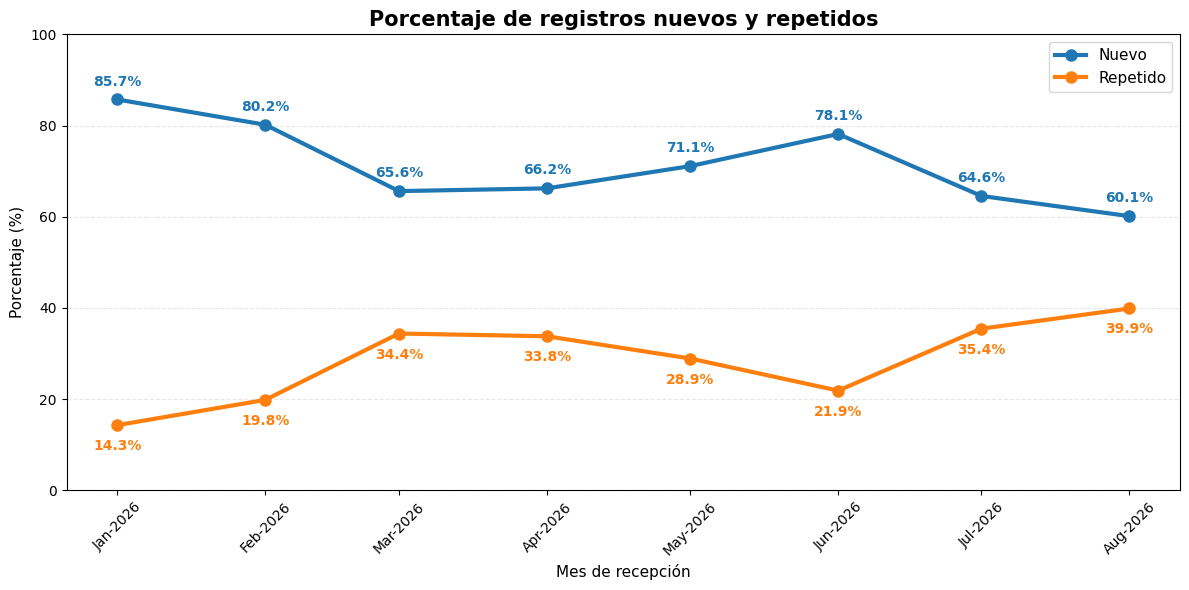

Tipo,Nuevo,Repetido,Total,Porcentaje_nuevo,Porcentaje_repetido
mes,,,,,
2026-01-01,41052,6843,47895,85.71,14.29
2026-02-01,73401,18154,91555,80.17,19.83
2026-03-01,65000,34058,99058,65.62,34.38
2026-04-01,24749,12625,37374,66.22,33.78
2026-05-01,24650,10022,34672,71.09,28.91
2026-06-01,44566,12466,57032,78.14,21.86
2026-07-01,40742,22370,63112,64.56,35.44
2026-08-01,19634,13022,32656,60.12,39.88


In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# ============================================================
df_grafico = df_filtrado.copy()

# Asegurar tipos
df_grafico["mes"] = pd.to_datetime(df_grafico["mes"])
df_grafico["diferencia"] = pd.to_numeric(df_grafico["diferencia"], errors="coerce")
df_grafico["cantidad"] = pd.to_numeric(df_grafico["cantidad"], errors="coerce").fillna(0)

# ============================================================
# NUEVO O REPETIDO
# ============================================================
df_grafico["Tipo"] = df_grafico["diferencia"].apply(
    lambda x: "Nuevo" if x == 0 else "Repetido"
)

# ============================================================
# RESUMEN MENSUAL
# ============================================================
df_resumen_grafico = (
    df_grafico
    .groupby(["mes", "Tipo"])["cantidad"]
    .sum()
    .unstack(fill_value=0)
)

# En caso de que falte alguna columna
for col in ["Nuevo", "Repetido"]:
    if col not in df_resumen_grafico.columns:
        df_resumen_grafico[col] = 0

df_resumen_grafico["Total"] = (
    df_resumen_grafico["Nuevo"] +
    df_resumen_grafico["Repetido"]
)

df_resumen_grafico["Porcentaje_nuevo"] = (
    df_resumen_grafico["Nuevo"] /
    df_resumen_grafico["Total"] * 100
)

df_resumen_grafico["Porcentaje_repetido"] = (
    df_resumen_grafico["Repetido"] /
    df_resumen_grafico["Total"] * 100
)

df_resumen_grafico = df_resumen_grafico.sort_index()

# ============================================================
# GRAFICO
# ============================================================
plt.figure(figsize=(12,6))

# Línea azul
plt.plot(
    df_resumen_grafico.index,
    df_resumen_grafico["Porcentaje_nuevo"],
    marker="o",
    linewidth=3,
    markersize=8,
    color="#1f77b4",
    label="Nuevo"
)

# Línea naranja
plt.plot(
    df_resumen_grafico.index,
    df_resumen_grafico["Porcentaje_repetido"],
    marker="o",
    linewidth=3,
    markersize=8,
    color="#ff7f0e",
    label="Repetido"
)

# ============================================================
# ETIQUETAS NUEVO
# ============================================================
for x, y in zip(
    df_resumen_grafico.index,
    df_resumen_grafico["Porcentaje_nuevo"]
):
    plt.annotate(
        f"{y:.1f}%",
        (x, y),
        xytext=(0,10),
        textcoords="offset points",
        ha="center",
        color="#1f77b4",
        fontsize=10,
        fontweight="bold"
    )

# ============================================================
# ETIQUETAS REPETIDO
# ============================================================
for x, y in zip(
    df_resumen_grafico.index,
    df_resumen_grafico["Porcentaje_repetido"]
):
    plt.annotate(
        f"{y:.1f}%",
        (x, y),
        xytext=(0,-18),
        textcoords="offset points",
        ha="center",
        color="#ff7f0e",
        fontsize=10,
        fontweight="bold"
    )

# ============================================================
# FORMATO
# ============================================================
plt.title(
    f"Porcentaje de registros nuevos y repetidos",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Mes de recepción", fontsize=11)
plt.ylabel("Porcentaje (%)", fontsize=11)

plt.ylim(0,100)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.legend(fontsize=11)

plt.xticks(
    df_resumen_grafico.index,
    [d.strftime("%b-%Y") for d in df_resumen_grafico.index],
    rotation=45
)

plt.tight_layout()

plt.show()

# ============================================================
# TABLA UTILIZADA
# ============================================================
display(
    df_resumen_grafico[
        [
            "Nuevo",
            "Repetido",
            "Total",
            "Porcentaje_nuevo",
            "Porcentaje_repetido"
        ]
    ].round(2)
)

In [ ]:
ruta_archivo = os.path.join(ruta_csv, 'negocios_2.xlsx')

df_dni.to_excel(ruta_archivo, index=False)

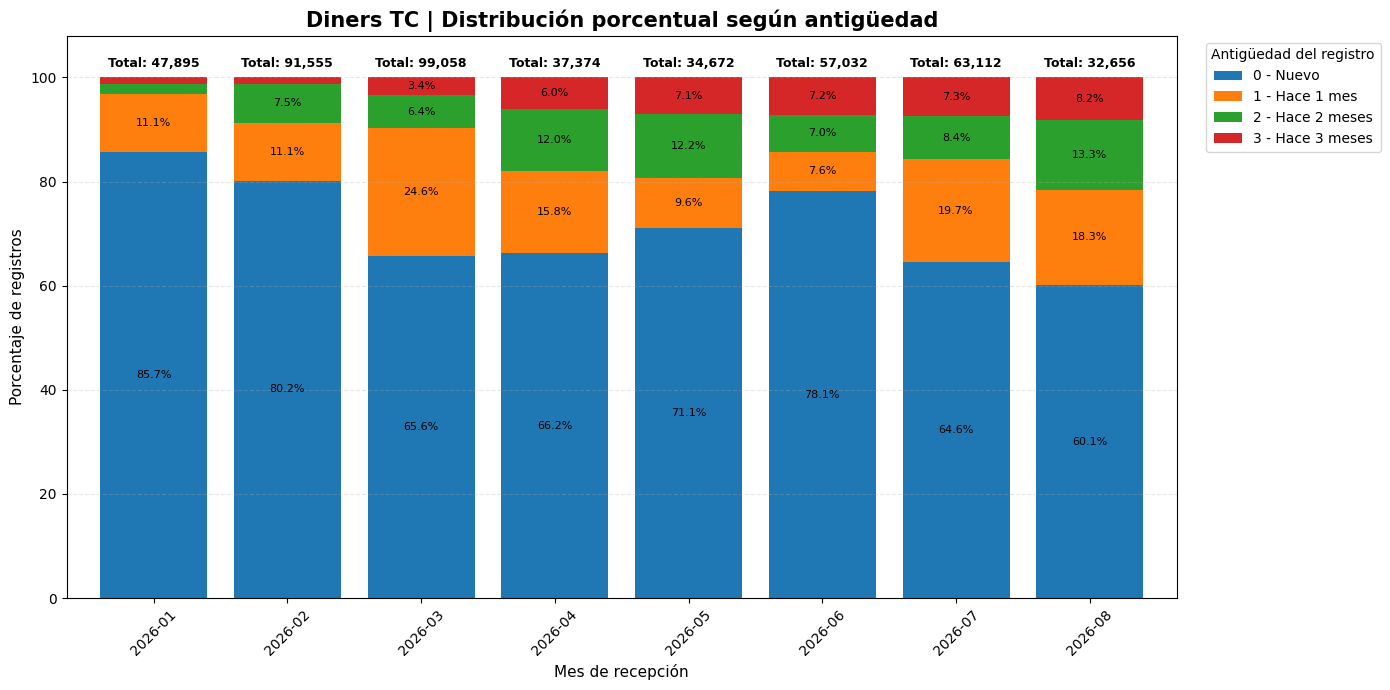

antiguedad,0 - Nuevo,1 - Hace 1 mes,2 - Hace 2 meses,3 - Hace 3 meses,Total base
mes,,,,,
2026-01-01,85.71%,11.13%,1.88%,1.28%,47895
2026-02-01,80.17%,11.14%,7.48%,1.21%,91555
2026-03-01,65.62%,24.61%,6.35%,3.42%,99058
2026-04-01,66.22%,15.78%,11.97%,6.03%,37374
2026-05-01,71.09%,9.56%,12.24%,7.10%,34672
2026-06-01,78.14%,7.63%,6.98%,7.25%,57032
2026-07-01,64.56%,19.71%,8.40%,7.33%,63112
2026-08-01,60.12%,18.28%,13.35%,8.25%,32656


In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CAMBIAR ÚNICAMENTE EL PROB_CONTACTO_ESTANDAR   
# ============================================================
df_grafico = df_filtrado.copy()

df_grafico["mes"] = pd.to_datetime(
    df_grafico["mes"],
    errors="coerce"
)

df_grafico["cantidad"] = pd.to_numeric(
    df_grafico["cantidad"],
    errors="coerce"
).fillna(0)

df_grafico["diferencia"] = pd.to_numeric(
    df_grafico["diferencia"],
    errors="coerce"
)

# Eliminar registros sin mes o diferencia
df_grafico = df_grafico.dropna(
    subset=["mes", "diferencia"]
)

# Convertir diferencia a entero
df_grafico["diferencia"] = (
    df_grafico["diferencia"]
    .astype(int)
)

# ============================================================
# CREAR ETIQUETA DE ANTIGÜEDAD
# ============================================================
def crear_etiqueta_diferencia(valor):
    if valor == 0:
        return "0 - Nuevo"
    elif valor == 1:
        return "1 - Hace 1 mes"
    else:
        return f"{valor} - Hace {valor} meses"



df_grafico["antiguedad"] = (
    df_grafico["diferencia"]
    .apply(crear_etiqueta_diferencia)
)

# ============================================================
# RESUMEN POR MES Y DIFERENCIA
# ============================================================
df_diferencia = (
    df_grafico
    .groupby(
        ["mes", "diferencia", "antiguedad"],
        as_index=False
    )["cantidad"]
    .sum()
)

# Orden correcto de las categorías
orden_antiguedad = (
    df_diferencia[
        ["diferencia", "antiguedad"]
    ]
    .drop_duplicates()
    .sort_values("diferencia")["antiguedad"]
    .tolist()
)

# ============================================================
# TABLA DE CANTIDADES
# ============================================================
df_diferencia_cantidad = (
    df_diferencia
    .pivot(
        index="mes",
        columns="antiguedad",
        values="cantidad"
    )
    .fillna(0)
    .sort_index()
)

# Mantener el orden: nuevo, 1 mes, 2 meses...
columnas_existentes = [
    columna
    for columna in orden_antiguedad
    if columna in df_diferencia_cantidad.columns
]

df_diferencia_cantidad = (
    df_diferencia_cantidad[
        columnas_existentes
    ]
)

# ============================================================
# TOTAL DE LA BASE POR MES
# ============================================================
df_diferencia_cantidad["Total base"] = (
    df_diferencia_cantidad.sum(axis=1)
)

# ============================================================
# TABLA EN PORCENTAJES
# ============================================================
df_diferencia_porcentaje = (
    df_diferencia_cantidad[
        columnas_existentes
    ]
    .div(
        df_diferencia_cantidad["Total base"],
        axis=0
    )
    * 100
)

# Añadir total de la base como cantidad
df_diferencia_porcentaje["Total base"] = (
    df_diferencia_cantidad["Total base"]
)

# ============================================================
# GRÁFICO DE BARRAS APILADAS AL 100%
# ============================================================
ax = df_diferencia_porcentaje[
    columnas_existentes
].plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7),
    width=0.80
)

# ============================================================
# ETIQUETAS DE PORCENTAJE DENTRO DE LAS BARRAS
# ============================================================
for contenedor in ax.containers:

    etiquetas = []

    for barra in contenedor:
        valor = barra.get_height()

        if valor >= 2:
            etiquetas.append(f"{valor:.1f}%")
        else:
            etiquetas.append("")

    ax.bar_label(
        contenedor,
        labels=etiquetas,
        label_type="center",
        fontsize=8
    )

# ============================================================
# TOTAL DE LA BASE ENCIMA DE CADA BARRA
# ============================================================
for posicion, total in enumerate(
    df_diferencia_porcentaje["Total base"]
):
    ax.text(
        posicion,
        101.5,
        f"Total: {total:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

# ============================================================
# FORMATO DEL GRÁFICO
# ============================================================
plt.title(
    f"Diners TC | Distribución porcentual según antigüedad",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Mes de recepción",
    fontsize=11
)

plt.ylabel(
    "Porcentaje de registros",
    fontsize=11
)

plt.xticks(
    range(len(df_diferencia_porcentaje.index)),
    [
        fecha.strftime("%Y-%m")
        for fecha in df_diferencia_porcentaje.index
    ],
    rotation=45
)

plt.ylim(0, 108)

plt.legend(
    title="Antigüedad del registro",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

# ============================================================
# TABLA FINAL PARA MOSTRAR
# ============================================================
df_tabla_final = (
    df_diferencia_porcentaje
    .copy()
)

# Dar formato de porcentaje a las columnas de antigüedad
for columna in columnas_existentes:
    df_tabla_final[columna] = (
        df_tabla_final[columna]
        .map(lambda x: f"{x:.2f}%")
    )

# Total base como entero
df_tabla_final["Total base"] = (
    df_tabla_final["Total base"]
    .astype(int)
)

display(df_tabla_final)

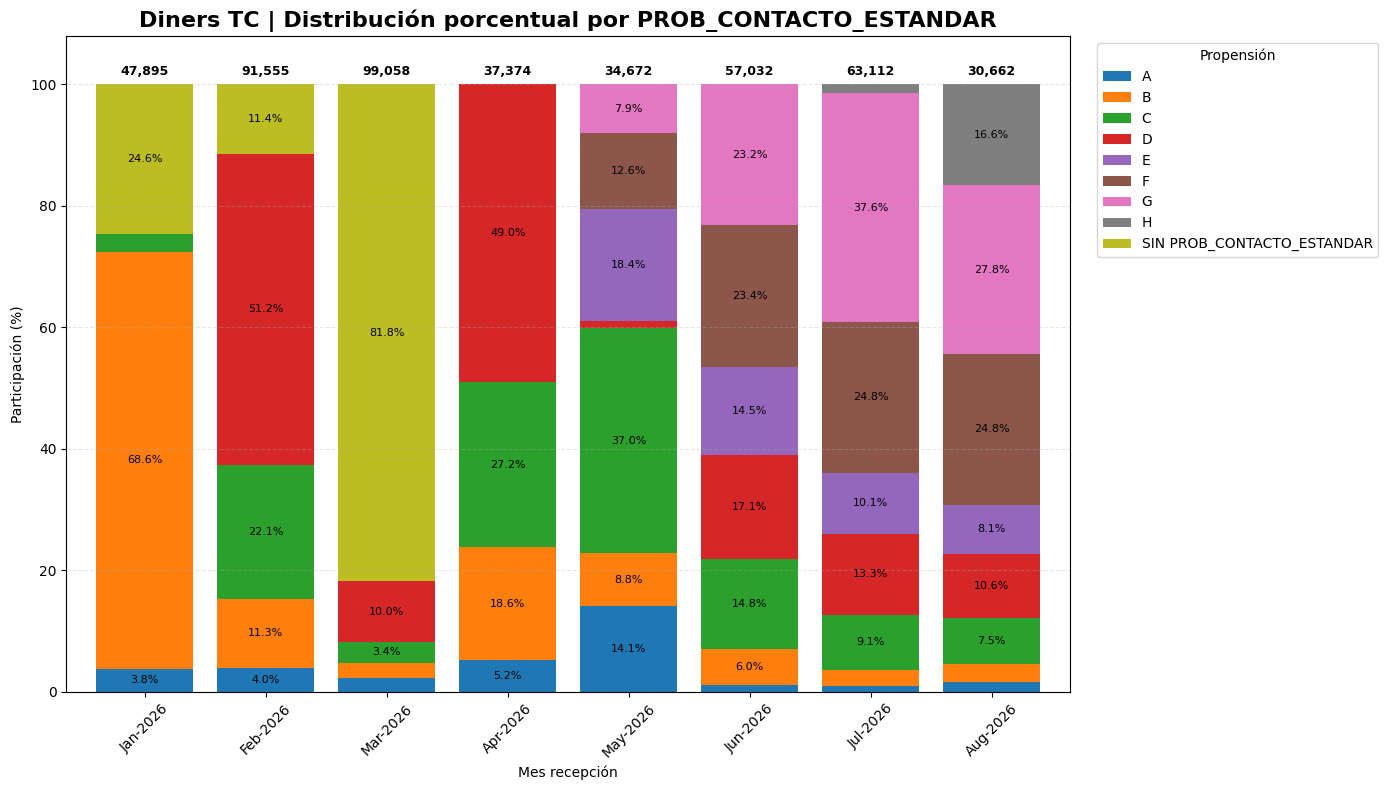

PROB_CONTACTO_ESTANDAR,A,B,C,D,E,F,G,H,SIN PROB_CONTACTO_ESTANDAR,Total Base
mes,,,,,,,,,,
2026-01-01,3.83%,68.60%,2.93%,0.00%,0.00%,0.00%,0.00%,0.00%,24.65%,47895
2026-02-01,3.97%,11.33%,22.07%,51.18%,0.00%,0.00%,0.00%,0.00%,11.45%,91555
2026-03-01,2.26%,2.54%,3.40%,9.96%,0.00%,0.00%,0.00%,0.00%,81.84%,99058
2026-04-01,5.17%,18.63%,27.15%,49.04%,0.00%,0.00%,0.00%,0.00%,0.00%,37374
2026-05-01,14.07%,8.76%,37.00%,1.26%,18.38%,12.59%,7.93%,0.00%,0.00%,34672
2026-06-01,1.04%,5.97%,14.77%,17.13%,14.52%,23.37%,23.20%,0.00%,0.00%,57032
2026-07-01,0.97%,2.64%,9.06%,13.35%,10.08%,24.82%,37.60%,1.48%,0.00%,63112
2026-08-01,1.62%,2.98%,7.50%,10.60%,8.10%,24.79%,27.79%,16.62%,0.00%,30662


In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CAMBIAR ÚNICAMENTE EL PRODUCTO
# ============================================================

# ============================================================
# FILTRAR
# ============================================================
df_grafico = df_filtrado.copy()

df_grafico["mes"] = pd.to_datetime(df_grafico["mes"])

df_grafico["cantidad"] = pd.to_numeric(
    df_grafico["cantidad"],
    errors="coerce"
).fillna(0)

df_grafico["PROB_CONTACTO_ESTANDAR"] = (
    df_grafico["PROB_CONTACTO_ESTANDAR"]
    .fillna("SIN PROB_CONTACTO_ESTANDAR")
    .astype(str)
    .str.upper()
    .str.strip()
)

# ============================================================
# TABLA DE CANTIDADES
# ============================================================
df_prop = (
    df_grafico
    .groupby(
        ["mes","PROB_CONTACTO_ESTANDAR"]
    )["cantidad"]
    .sum()
    .unstack(fill_value=0)
)

# Orden de las columnas
orden = [
    "A",
    "B",
    "C",
    "D",
    "E",
    "F",
    "G",
    "H",
    "SIN PROB_CONTACTO_ESTANDAR"
]

columnas = [
    c
    for c in orden
    if c in df_prop.columns
]

df_prop = df_prop[columnas]

# ============================================================
# TOTAL BASE
# ============================================================
df_prop["Total Base"] = df_prop.sum(axis=1)

# ============================================================
# PORCENTAJES
# ============================================================
df_prop_pct = (
    df_prop[columnas]
    .div(df_prop["Total Base"],axis=0)
    *100
)

# Guardar total
df_prop_pct["Total Base"] = df_prop["Total Base"]

# ============================================================
# GRAFICO APILADO
# ============================================================
ax = df_prop_pct[columnas].plot(
    kind="bar",
    stacked=True,
    figsize=(14,8),
    width=0.80
)

# Etiquetas
for contenedor in ax.containers:

    etiquetas=[]

    for barra in contenedor:

        valor=barra.get_height()

        if valor>=3:
            etiquetas.append(f"{valor:.1f}%")
        else:
            etiquetas.append("")

    ax.bar_label(
        contenedor,
        labels=etiquetas,
        label_type="center",
        fontsize=8
    )

# Total encima
for x,total in enumerate(df_prop_pct["Total Base"]):

    ax.text(
        x,
        101.5,
        f"{int(total):,}",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.title(
    f"Diners TC | Distribución porcentual por PROB_CONTACTO_ESTANDAR",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Participación (%)")
plt.xlabel("Mes recepción")

plt.xticks(
    range(len(df_prop_pct.index)),
    [
        fecha.strftime("%b-%Y")
        for fecha in df_prop_pct.index
    ],
    rotation=45
)

plt.ylim(0,108)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=.3
)

plt.legend(
    title="Propensión",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

# ============================================================
# TABLA
# ============================================================

tabla=df_prop_pct.copy()

for c in columnas:
    tabla[c]=tabla[c].map(lambda x:f"{x:.2f}%")

tabla["Total Base"]=tabla["Total Base"].astype(int)

display(tabla)

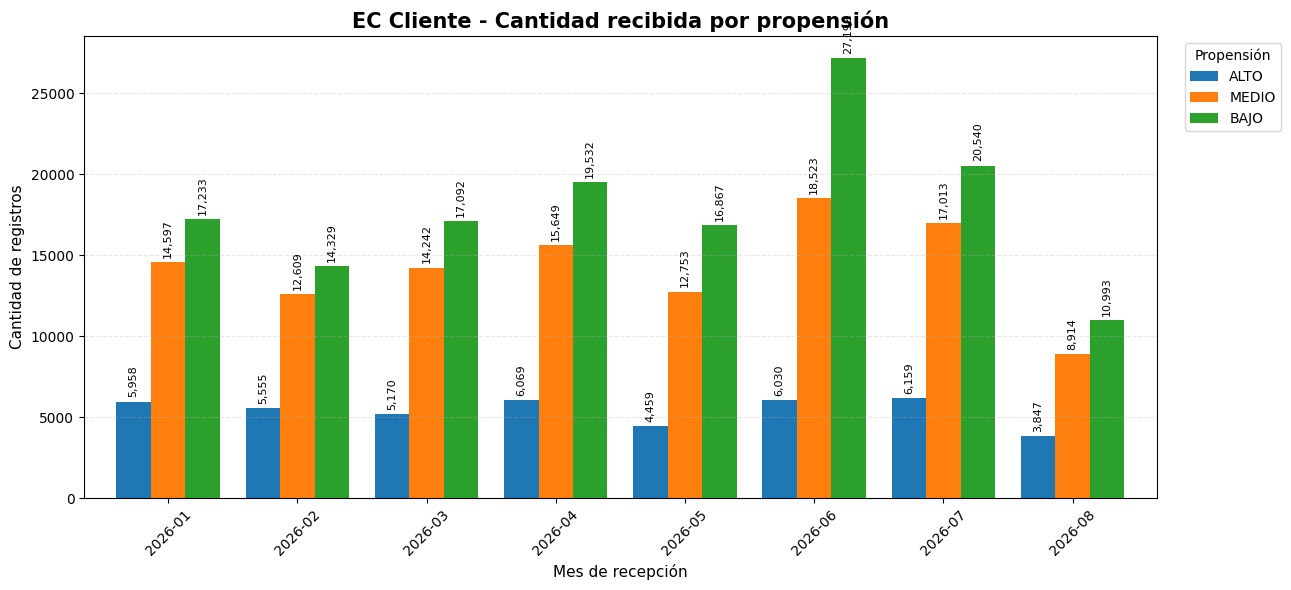

PROPENSION,ALTO,MEDIO,BAJO
mes,,,
2026-01-01,5958,14597,17233
2026-02-01,5555,12609,14329
2026-03-01,5170,14242,17092
2026-04-01,6069,15649,19532
2026-05-01,4459,12753,16867
2026-06-01,6030,18523,27199
2026-07-01,6159,17013,20540
2026-08-01,3847,8914,10993


In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CAMBIAR ÚNICAMENTE EL PRODUCTO
# ============================================================
producto_seleccionado = "EC Cliente"

# ============================================================
# FILTRAR Y PREPARAR DATOS
# ============================================================
df_grafico = df_filtrado[
    df_filtrado["producto"] == producto_seleccionado
].copy()

df_grafico["mes"] = pd.to_datetime(
    df_grafico["mes"],
    errors="coerce"
)

df_grafico["cantidad"] = pd.to_numeric(
    df_grafico["cantidad"],
    errors="coerce"
).fillna(0)

# Reemplazar propensión nula
df_grafico["PROPENSION"] = (
    df_grafico["PROPENSION"]
    .fillna("SIN PROPENSION")
    .astype(str)
    .str.strip()
)

# ============================================================
# CANTIDAD POR MES Y PROPENSIÓN
# ============================================================
df_propension = (
    df_grafico
    .groupby(
        ["mes", "PROPENSION"],
        as_index=False
    )["cantidad"]
    .sum()
)

# Convertir a formato ancho
df_propension_pivot = (
    df_propension
    .pivot(
        index="mes",
        columns="PROPENSION",
        values="cantidad"
    )
    .fillna(0)
    .sort_index()
)

# Orden deseado de las propensiones
orden_propension = [
    "ALTO",
    "MEDIO",
    "BAJO",
    "SIN PROPENSION"
]

columnas_existentes = [
    columna
    for columna in orden_propension
    if columna in df_propension_pivot.columns
]

# Agregar cualquier otra propensión que exista
otras_columnas = [
    columna
    for columna in df_propension_pivot.columns
    if columna not in columnas_existentes
]

columnas_grafico = columnas_existentes + otras_columnas

# ============================================================
# GRÁFICO DE BARRAS AGRUPADAS
# ============================================================
ax = df_propension_pivot[columnas_grafico].plot(
    kind="bar",
    figsize=(13, 6),
    width=0.80
)

# Colocar cantidades encima de las barras
for contenedor in ax.containers:
    etiquetas = [
        f"{barra.get_height():,.0f}"
        if barra.get_height() > 0
        else ""
        for barra in contenedor
    ]

    ax.bar_label(
        contenedor,
        labels=etiquetas,
        padding=3,
        fontsize=8,
        rotation=90
    )

# ============================================================
# FORMATO
# ============================================================
plt.title(
    f"{producto_seleccionado} - Cantidad recibida por propensión",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Mes de recepción", fontsize=11)
plt.ylabel("Cantidad de registros", fontsize=11)

plt.xticks(
    range(len(df_propension_pivot.index)),
    [
        fecha.strftime("%Y-%m")
        for fecha in df_propension_pivot.index
    ],
    rotation=45
)

plt.legend(
    title="Propensión",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

# ============================================================
# MOSTRAR TABLA UTILIZADA
# ============================================================
display(
    df_propension_pivot[columnas_grafico]
    .astype(int)
)

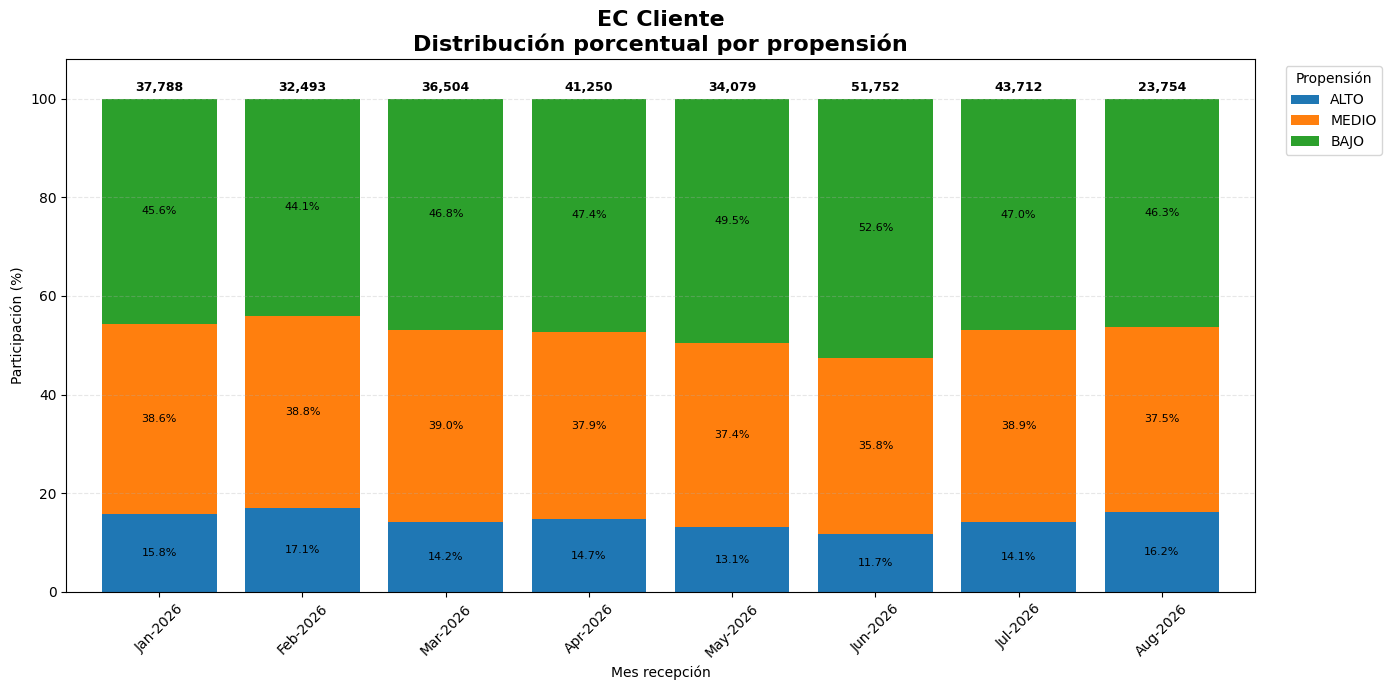

PROPENSION,ALTO,MEDIO,BAJO,Total Base
mes,,,,
2026-01-01,15.77%,38.63%,45.60%,37788
2026-02-01,17.10%,38.81%,44.10%,32493
2026-03-01,14.16%,39.01%,46.82%,36504
2026-04-01,14.71%,37.94%,47.35%,41250
2026-05-01,13.08%,37.42%,49.49%,34079
2026-06-01,11.65%,35.79%,52.56%,51752
2026-07-01,14.09%,38.92%,46.99%,43712
2026-08-01,16.20%,37.53%,46.28%,23754


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CAMBIAR ÚNICAMENTE EL PRODUCTO
# ============================================================

# ============================================================
# FILTRAR
# ============================================================
df_grafico = df_filtrado.copy()

df_grafico["mes"] = pd.to_datetime(df_grafico["mes"])

df_grafico["cantidad"] = pd.to_numeric(
    df_grafico["cantidad"],
    errors="coerce"
).fillna(0)

df_grafico["PROPENSION"] = (
    df_grafico["PROPENSION"]
    .fillna("SIN PROPENSION")
    .astype(str)
    .str.upper()
    .str.strip()
)

# ============================================================
# TABLA DE CANTIDADES
# ============================================================
df_prop = (
    df_grafico
    .groupby(
        ["mes","PROPENSION"]
    )["cantidad"]
    .sum()
    .unstack(fill_value=0)
)

# Orden de las columnas
orden = [
    "ALTO",
    "MEDIO",
    "BAJO",
    "SIN PROPENSION"
]

columnas = [
    c
    for c in orden
    if c in df_prop.columns
]

df_prop = df_prop[columnas]

# ============================================================
# TOTAL BASE
# ============================================================
df_prop["Total Base"] = df_prop.sum(axis=1)

# ============================================================
# PORCENTAJES
# ============================================================
df_prop_pct = (
    df_prop[columnas]
    .div(df_prop["Total Base"],axis=0)
    *100
)

# Guardar total
df_prop_pct["Total Base"] = df_prop["Total Base"]

# ============================================================
# GRAFICO APILADO
# ============================================================
ax = df_prop_pct[columnas].plot(
    kind="bar",
    stacked=True,
    figsize=(14,7),
    width=0.80
)

# Etiquetas
for contenedor in ax.containers:

    etiquetas=[]

    for barra in contenedor:

        valor=barra.get_height()

        if valor>=3:
            etiquetas.append(f"{valor:.1f}%")
        else:
            etiquetas.append("")

    ax.bar_label(
        contenedor,
        labels=etiquetas,
        label_type="center",
        fontsize=8
    )

# Total encima
for x,total in enumerate(df_prop_pct["Total Base"]):

    ax.text(
        x,
        101.5,
        f"{int(total):,}",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.title(
    f"Distribución porcentual por Prioridad",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Participación (%)")
plt.xlabel("Mes recepción")

plt.xticks(
    range(len(df_prop_pct.index)),
    [
        fecha.strftime("%b-%Y")
        for fecha in df_prop_pct.index
    ],
    rotation=45
)

plt.ylim(0,108)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=.3
)

plt.legend(
    title="Propensión",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

# ============================================================
# TABLA
# ============================================================

tabla=df_prop_pct.copy()

for c in columnas:
    tabla[c]=tabla[c].map(lambda x:f"{x:.2f}%")

tabla["Total Base"]=tabla["Total Base"].astype(int)

display(tabla)

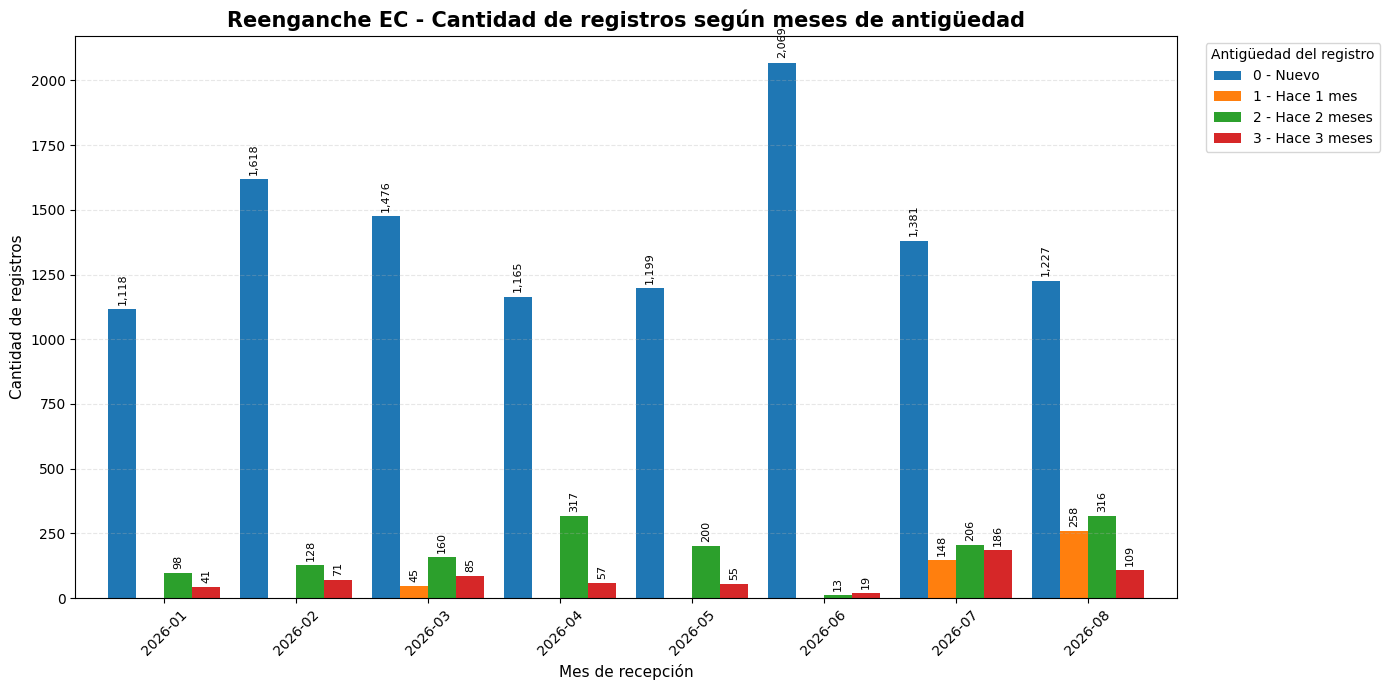

antiguedad,0 - Nuevo,1 - Hace 1 mes,2 - Hace 2 meses,3 - Hace 3 meses
mes,,,,
2026-01-01,1118,0,98,41
2026-02-01,1618,0,128,71
2026-03-01,1476,45,160,85
2026-04-01,1165,0,317,57
2026-05-01,1199,0,200,55
2026-06-01,2069,0,13,19
2026-07-01,1381,148,206,186
2026-08-01,1227,258,316,109


In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CAMBIAR ÚNICAMENTE EL PRODUCTO
# ============================================================
producto_seleccionado = "Reenganche EC"

# ============================================================
# FILTRAR Y PREPARAR LOS DATOS
# ============================================================
df_grafico = df_filtrado[
    df_filtrado["producto"] == producto_seleccionado
].copy()

df_grafico["mes"] = pd.to_datetime(
    df_grafico["mes"],
    errors="coerce"
)

df_grafico["cantidad"] = pd.to_numeric(
    df_grafico["cantidad"],
    errors="coerce"
).fillna(0)

df_grafico["diferencia"] = pd.to_numeric(
    df_grafico["diferencia"],
    errors="coerce"
)

# Eliminar registros sin diferencia
df_grafico = df_grafico.dropna(subset=["mes", "diferencia"])

# Convertir diferencia a entero
df_grafico["diferencia"] = df_grafico["diferencia"].astype(int)

# ============================================================
# CREAR ETIQUETA DE ANTIGÜEDAD
# ============================================================
def crear_etiqueta_diferencia(valor):
    if valor == 0:
        return "0 - Nuevo"
    elif valor == 1:
        return "1 - Hace 1 mes"
    else:
        return f"{valor} - Hace {valor} meses"


df_grafico["antiguedad"] = df_grafico["diferencia"].apply(
    crear_etiqueta_diferencia
)

# ============================================================
# RESUMEN POR MES Y DIFERENCIA
# ============================================================
df_diferencia = (
    df_grafico
    .groupby(
        ["mes", "diferencia", "antiguedad"],
        as_index=False
    )["cantidad"]
    .sum()
)

# Crear orden de las categorías según diferencia
orden_antiguedad = (
    df_diferencia[
        ["diferencia", "antiguedad"]
    ]
    .drop_duplicates()
    .sort_values("diferencia")["antiguedad"]
    .tolist()
)

# Convertir a formato ancho
df_diferencia_pivot = (
    df_diferencia
    .pivot(
        index="mes",
        columns="antiguedad",
        values="cantidad"
    )
    .fillna(0)
    .sort_index()
)

# Mantener orden lógico: nuevo, 1 mes, 2 meses, etc.
columnas_existentes = [
    columna
    for columna in orden_antiguedad
    if columna in df_diferencia_pivot.columns
]

df_diferencia_pivot = df_diferencia_pivot[
    columnas_existentes
]

# ============================================================
# GRÁFICO DE BARRAS AGRUPADAS
# ============================================================
ax = df_diferencia_pivot.plot(
    kind="bar",
    figsize=(14, 7),
    width=0.85
)

# Agregar cantidades sobre cada barra
for contenedor in ax.containers:

    etiquetas = [
        f"{barra.get_height():,.0f}"
        if barra.get_height() > 0
        else ""
        for barra in contenedor
    ]

    ax.bar_label(
        contenedor,
        labels=etiquetas,
        padding=3,
        fontsize=8,
        rotation=90
    )

# ============================================================
# FORMATO DEL GRÁFICO
# ============================================================
plt.title(
    f"{producto_seleccionado} - Cantidad de registros según meses de antigüedad",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Mes de recepción",
    fontsize=11
)

plt.ylabel(
    "Cantidad de registros",
    fontsize=11
)

plt.xticks(
    range(len(df_diferencia_pivot.index)),
    [
        fecha.strftime("%Y-%m")
        for fecha in df_diferencia_pivot.index
    ],
    rotation=45
)

plt.legend(
    title="Antigüedad del registro",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

# ============================================================
# TABLA UTILIZADA
# ============================================================
display(
    df_diferencia_pivot.astype(int)
)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

producto = "Reenganche EC"

df = df_filtrado[df_filtrado["producto"] == producto].copy()

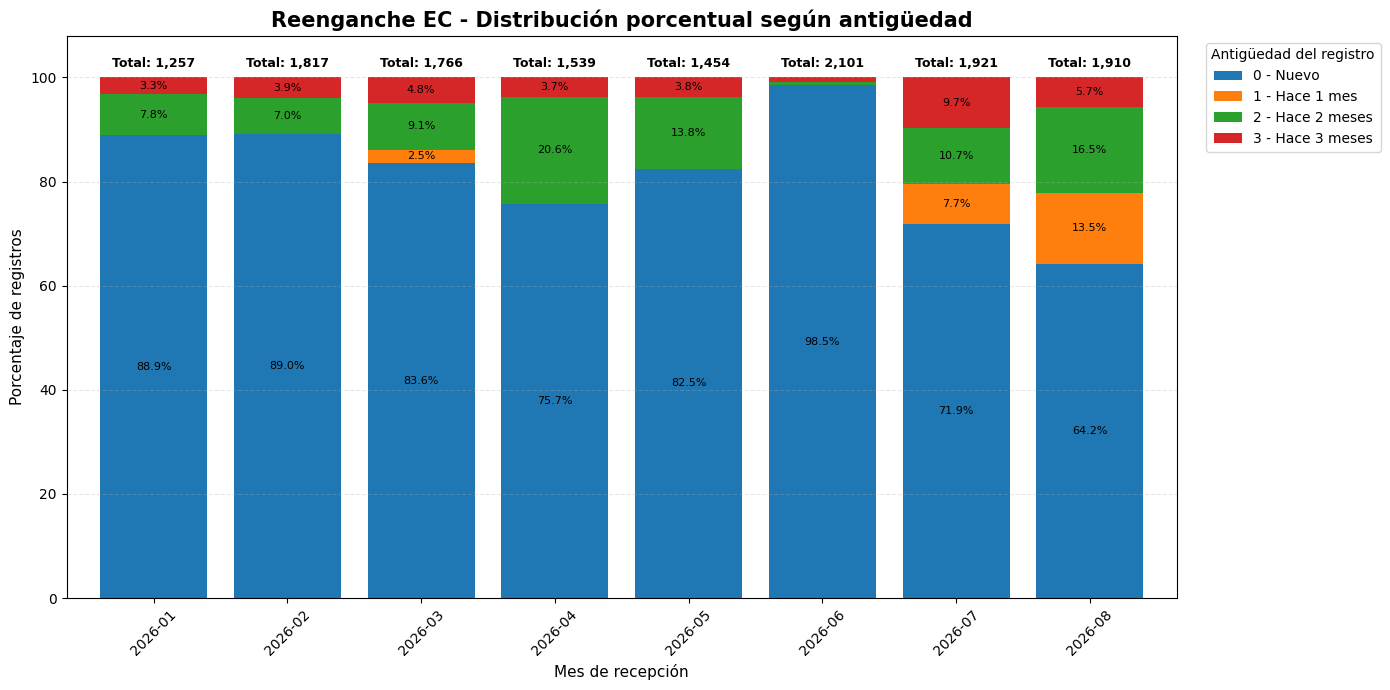

antiguedad,0 - Nuevo,1 - Hace 1 mes,2 - Hace 2 meses,3 - Hace 3 meses,Total base
mes,,,,,
2026-01-01,88.94%,0.00%,7.80%,3.26%,1257
2026-02-01,89.05%,0.00%,7.04%,3.91%,1817
2026-03-01,83.58%,2.55%,9.06%,4.81%,1766
2026-04-01,75.70%,0.00%,20.60%,3.70%,1539
2026-05-01,82.46%,0.00%,13.76%,3.78%,1454
2026-06-01,98.48%,0.00%,0.62%,0.90%,2101
2026-07-01,71.89%,7.70%,10.72%,9.68%,1921
2026-08-01,64.24%,13.51%,16.54%,5.71%,1910


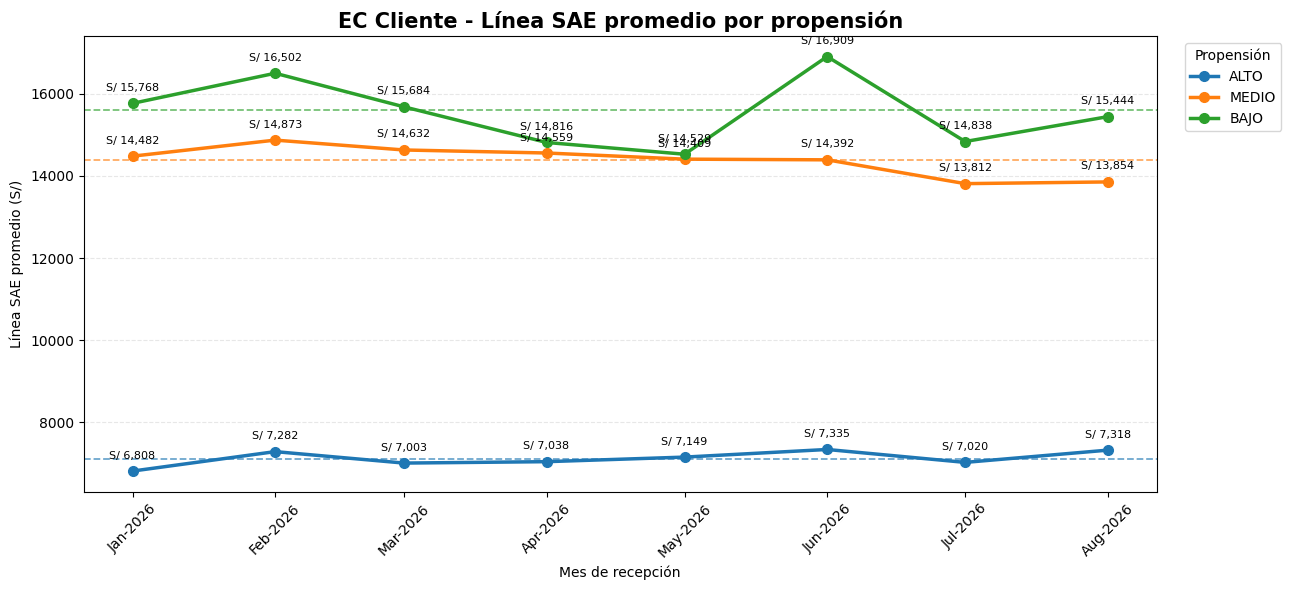

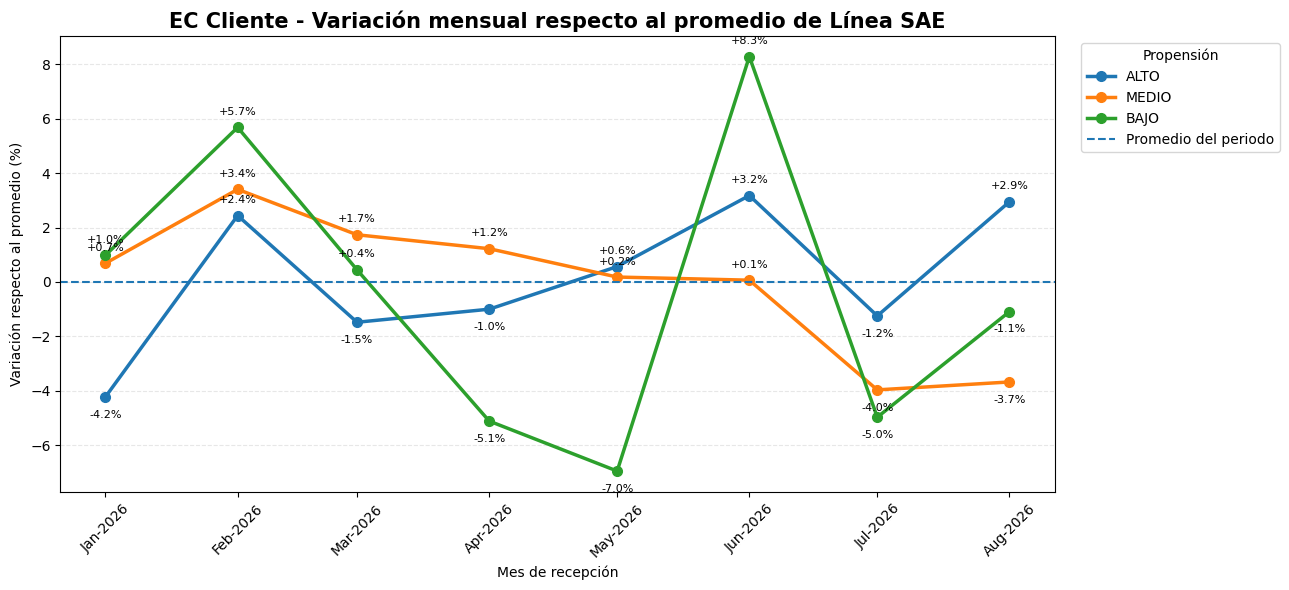

,Propensión,Promedio Línea SAE,Mínimo mensual,Máximo mensual,Desviación estándar,Coeficiente de variación,Rango respecto al promedio,Nivel de estabilidad
0,ALTO,"S/ 7,108.70","S/ 6,808.43","S/ 7,334.61",S/ 185.18,2.60%,7.40%,Muy estable
1,MEDIO,"S/ 14,382.94","S/ 13,812.19","S/ 14,872.77",S/ 368.17,2.56%,7.37%,Muy estable
2,BAJO,"S/ 15,614.66","S/ 14,528.82","S/ 16,908.71",S/ 838.11,5.37%,15.24%,Estable


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CAMBIAR ÚNICAMENTE EL PRODUCTO
# ============================================================
producto_seleccionado = "EC Cliente"

# Orden deseado
orden_propension = ["ALTO", "MEDIO", "BAJO"]

# ============================================================
# 1. FILTRAR Y PREPARAR DATOS
# ============================================================
df_grafico = df_filtrado[
    df_filtrado["producto"] == producto_seleccionado
].copy()

df_grafico["mes"] = pd.to_datetime(
    df_grafico["mes"],
    errors="coerce"
)

df_grafico["linea_sae_sum"] = pd.to_numeric(
    df_grafico["linea_sae_sum"],
    errors="coerce"
).fillna(0)

df_grafico["linea_sae_count"] = pd.to_numeric(
    df_grafico["linea_sae_count"],
    errors="coerce"
).fillna(0)

df_grafico["PROPENSION"] = (
    df_grafico["PROPENSION"]
    .fillna("SIN PROPENSION")
    .astype(str)
    .str.strip()
    .str.upper()
)

# Conservar únicamente ALTO, MEDIO y BAJO
df_grafico = df_grafico[
    df_grafico["PROPENSION"].isin(orden_propension)
].copy()

# Eliminar registros sin mes o sin observaciones de Línea SAE
df_grafico = df_grafico[
    df_grafico["mes"].notna()
    & (df_grafico["linea_sae_count"] > 0)
].copy()

# ============================================================
# 2. PROMEDIO PONDERADO POR MES Y PROPENSIÓN
# ============================================================
df_mensual = (
    df_grafico
    .groupby(
        ["mes", "PROPENSION"],
        as_index=False
    )
    .agg(
        linea_sae_sum=("linea_sae_sum", "sum"),
        linea_sae_count=("linea_sae_count", "sum")
    )
)

df_mensual["Promedio_linea_sae"] = (
    df_mensual["linea_sae_sum"]
    / df_mensual["linea_sae_count"]
)

# Pasar a formato ancho
df_linea_sae = (
    df_mensual
    .pivot(
        index="mes",
        columns="PROPENSION",
        values="Promedio_linea_sae"
    )
    .sort_index()
)

# Mantener orden de las propensiones
columnas_existentes = [
    columna
    for columna in orden_propension
    if columna in df_linea_sae.columns
]

df_linea_sae = df_linea_sae[columnas_existentes]

# ============================================================
# 3. PROMEDIO PONDERADO DEL PERIODO POR PROPENSIÓN
# ============================================================
df_periodo = (
    df_grafico
    .groupby("PROPENSION", as_index=False)
    .agg(
        linea_sae_sum=("linea_sae_sum", "sum"),
        linea_sae_count=("linea_sae_count", "sum")
    )
)

df_periodo["Promedio_periodo"] = (
    df_periodo["linea_sae_sum"]
    / df_periodo["linea_sae_count"]
)

promedios_periodo = (
    df_periodo
    .set_index("PROPENSION")["Promedio_periodo"]
    .to_dict()
)

# ============================================================
# 4. GRÁFICO 1:
# EVOLUCIÓN MENSUAL DE LA LÍNEA SAE PROMEDIO
# ============================================================
fig, ax = plt.subplots(figsize=(13, 6))

for propension in columnas_existentes:

    linea, = ax.plot(
        df_linea_sae.index,
        df_linea_sae[propension],
        marker="o",
        linewidth=2.5,
        markersize=7,
        label=propension
    )

    # Valores mensuales
    for mes, valor in df_linea_sae[propension].dropna().items():
        ax.annotate(
            f"S/ {valor:,.0f}",
            xy=(mes, valor),
            xytext=(0, 9),
            textcoords="offset points",
            ha="center",
            fontsize=8
        )

    # Promedio del periodo: línea horizontal punteada
    promedio = promedios_periodo.get(propension)

    if pd.notna(promedio):
        ax.axhline(
            y=promedio,
            linestyle="--",
            linewidth=1.3,
            alpha=0.65,
            color=linea.get_color()
        )

ax.set_title(
    f"{producto_seleccionado} - Línea SAE promedio por propensión",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Mes de recepción")
ax.set_ylabel("Línea SAE promedio (S/)")

ax.set_xticks(df_linea_sae.index)
ax.set_xticklabels(
    [
        fecha.strftime("%b-%Y")
        for fecha in df_linea_sae.index
    ],
    rotation=45
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend(
    title="Propensión",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# ============================================================
# 5. CALCULAR VARIACIÓN FRENTE AL PROMEDIO DEL PERIODO
# ============================================================
df_variacion = df_linea_sae.copy()

for propension in columnas_existentes:

    promedio = promedios_periodo[propension]

    df_variacion[propension] = (
        (
            df_linea_sae[propension]
            / promedio
        ) - 1
    ) * 100

# ============================================================
# 6. GRÁFICO 2:
# VARIACIÓN PORCENTUAL RESPECTO AL PROMEDIO
# ============================================================
fig, ax = plt.subplots(figsize=(13, 6))

for propension in columnas_existentes:

    ax.plot(
        df_variacion.index,
        df_variacion[propension],
        marker="o",
        linewidth=2.5,
        markersize=7,
        label=propension
    )

    for mes, valor in df_variacion[propension].dropna().items():
        ax.annotate(
            f"{valor:+.1f}%",
            xy=(mes, valor),
            xytext=(0, 9 if valor >= 0 else -15),
            textcoords="offset points",
            ha="center",
            fontsize=8
        )

# Línea central: promedio del periodo
ax.axhline(
    y=0,
    linestyle="--",
    linewidth=1.5,
    label="Promedio del periodo"
)

ax.set_title(
    f"{producto_seleccionado} - Variación mensual respecto al promedio de Línea SAE",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Mes de recepción")
ax.set_ylabel("Variación respecto al promedio (%)")

ax.set_xticks(df_variacion.index)
ax.set_xticklabels(
    [
        fecha.strftime("%b-%Y")
        for fecha in df_variacion.index
    ],
    rotation=45
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend(
    title="Propensión",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# ============================================================
# 7. TABLA RESUMEN DE ESTABILIDAD
# ============================================================
resumen_estabilidad = []

for propension in columnas_existentes:

    valores = df_linea_sae[propension].dropna()

    promedio = promedios_periodo[propension]
    minimo = valores.min()
    maximo = valores.max()
    desviacion = valores.std()

    coeficiente_variacion = (
        desviacion / promedio * 100
        if promedio != 0
        else 0
    )

    rango_porcentual = (
        (maximo - minimo) / promedio * 100
        if promedio != 0
        else 0
    )

    resumen_estabilidad.append({
        "Propensión": propension,
        "Promedio Línea SAE": promedio,
        "Mínimo mensual": minimo,
        "Máximo mensual": maximo,
        "Desviación estándar": desviacion,
        "Coeficiente de variación": coeficiente_variacion,
        "Rango respecto al promedio": rango_porcentual
    })

df_resumen_estabilidad = pd.DataFrame(resumen_estabilidad)

# Clasificación orientativa
df_resumen_estabilidad["Nivel de estabilidad"] = (
    df_resumen_estabilidad["Coeficiente de variación"]
    .apply(
        lambda x: (
            "Muy estable" if x < 5
            else "Estable" if x < 10
            else "Variable"
        )
    )
)

# Dar formato para mostrar
df_tabla_final = df_resumen_estabilidad.copy()

for columna in [
    "Promedio Línea SAE",
    "Mínimo mensual",
    "Máximo mensual",
    "Desviación estándar"
]:
    df_tabla_final[columna] = df_tabla_final[columna].map(
        lambda x: f"S/ {x:,.2f}"
    )

for columna in [
    "Coeficiente de variación",
    "Rango respecto al promedio"
]:
    df_tabla_final[columna] = df_tabla_final[columna].map(
        lambda x: f"{x:.2f}%"
    )

display(df_tabla_final)

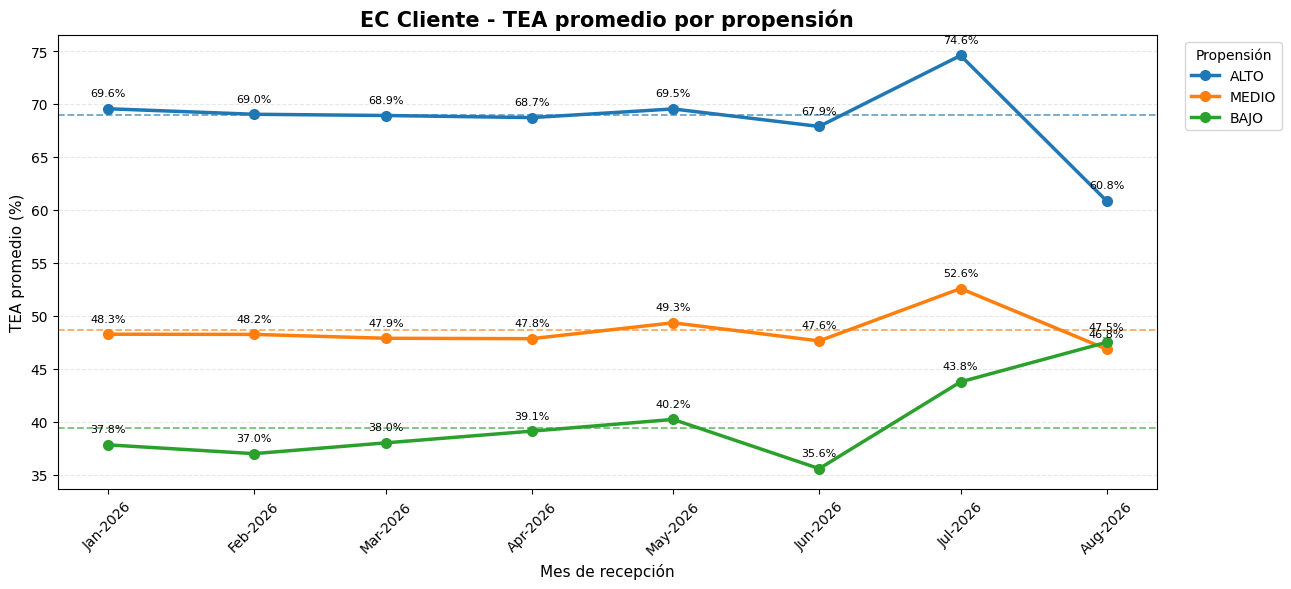

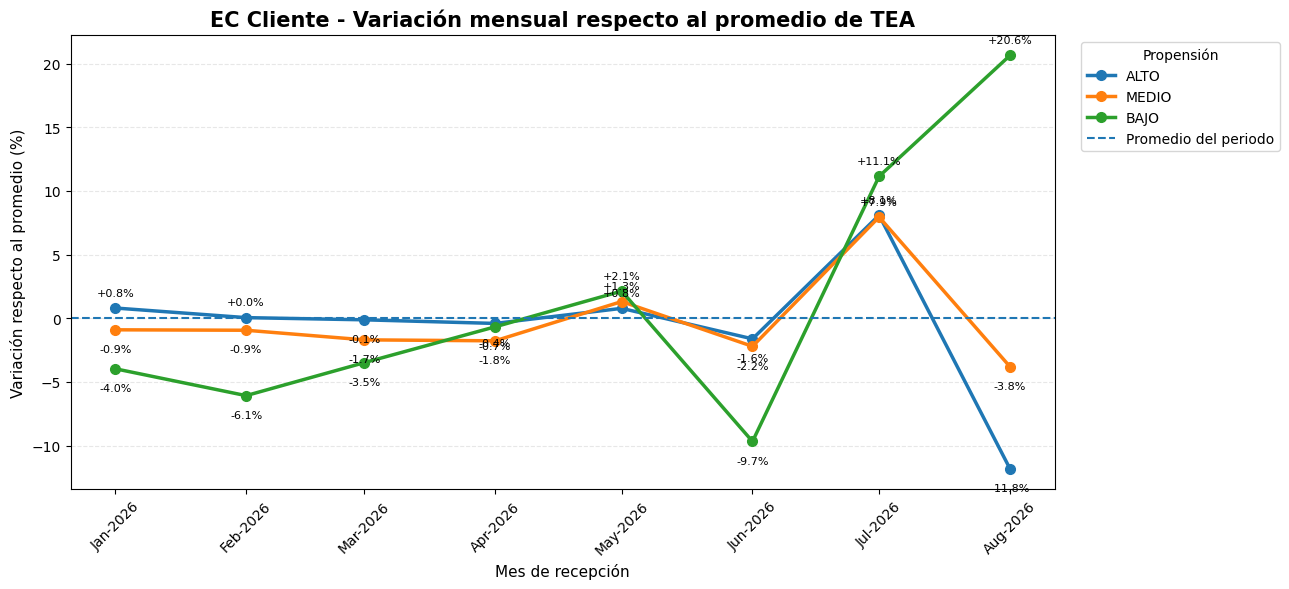

,Propensión,TEA promedio del periodo,TEA mínima mensual,TEA máxima mensual,Desviación estándar,Coeficiente de variación,Rango en puntos porcentuales,Nivel de estabilidad
0,ALTO,69.00%,60.85%,74.58%,3.75%,5.44%,13.73%,Estable
1,MEDIO,48.70%,46.85%,52.57%,1.76%,3.61%,5.72%,Muy estable
2,BAJO,39.37%,35.56%,47.49%,3.94%,10.01%,11.93%,Variable


In [55]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CAMBIAR ÚNICAMENTE EL PRODUCTO
# ============================================================
producto_seleccionado = "EC Cliente"

# Orden de los segmentos
orden_propension = ["ALTO", "MEDIO", "BAJO"]

# ============================================================
# 1. FILTRAR Y PREPARAR DATOS
# ============================================================
df_grafico = df_filtrado[
    df_filtrado["producto"] == producto_seleccionado
].copy()

df_grafico["mes"] = pd.to_datetime(
    df_grafico["mes"],
    errors="coerce"
)

df_grafico["tea_sum"] = pd.to_numeric(
    df_grafico["tea_sum"],
    errors="coerce"
).fillna(0)

df_grafico["tea_count"] = pd.to_numeric(
    df_grafico["tea_count"],
    errors="coerce"
).fillna(0)

df_grafico["PROPENSION"] = (
    df_grafico["PROPENSION"]
    .fillna("SIN PROPENSION")
    .astype(str)
    .str.strip()
    .str.upper()
)

# Conservar solo ALTO, MEDIO y BAJO
df_grafico = df_grafico[
    df_grafico["PROPENSION"].isin(orden_propension)
].copy()

# Eliminar registros sin mes o sin datos válidos de TEA
df_grafico = df_grafico[
    df_grafico["mes"].notna()
    & (df_grafico["tea_count"] > 0)
].copy()

# ============================================================
# 2. CALCULAR TEA PROMEDIO PONDERADA POR MES Y PROPENSIÓN
# ============================================================
df_tea_mensual = (
    df_grafico
    .groupby(
        ["mes", "PROPENSION"],
        as_index=False
    )
    .agg(
        tea_sum=("tea_sum", "sum"),
        tea_count=("tea_count", "sum")
    )
)

# La TEA original está expresada como decimal:
# 0.6955 = 69.55 %
df_tea_mensual["Promedio_TEA"] = (
    df_tea_mensual["tea_sum"]
    / df_tea_mensual["tea_count"]
    * 100
)

# Formato ancho
df_tea = (
    df_tea_mensual
    .pivot(
        index="mes",
        columns="PROPENSION",
        values="Promedio_TEA"
    )
    .sort_index()
)

columnas_existentes = [
    propension
    for propension in orden_propension
    if propension in df_tea.columns
]

df_tea = df_tea[columnas_existentes]

# ============================================================
# 3. TEA PROMEDIO PONDERADA DEL PERIODO POR PROPENSIÓN
# ============================================================
df_tea_periodo = (
    df_grafico
    .groupby(
        "PROPENSION",
        as_index=False
    )
    .agg(
        tea_sum=("tea_sum", "sum"),
        tea_count=("tea_count", "sum")
    )
)

df_tea_periodo["Promedio_periodo"] = (
    df_tea_periodo["tea_sum"]
    / df_tea_periodo["tea_count"]
    * 100
)

promedios_periodo = (
    df_tea_periodo
    .set_index("PROPENSION")["Promedio_periodo"]
    .to_dict()
)

# ============================================================
# 4. GRÁFICO 1:
# EVOLUCIÓN DE LA TEA PROMEDIO POR PROPENSIÓN
# ============================================================
fig, ax = plt.subplots(figsize=(13, 6))

for propension in columnas_existentes:

    linea, = ax.plot(
        df_tea.index,
        df_tea[propension],
        marker="o",
        linewidth=2.5,
        markersize=7,
        label=propension
    )

    # Etiquetas mensuales
    for mes, valor in df_tea[propension].dropna().items():
        ax.annotate(
            f"{valor:.1f}%",
            xy=(mes, valor),
            xytext=(0, 9),
            textcoords="offset points",
            ha="center",
            fontsize=8
        )

    # Línea punteada: promedio del periodo
    promedio = promedios_periodo.get(propension)

    if promedio is not None and pd.notna(promedio):
        ax.axhline(
            y=promedio,
            linestyle="--",
            linewidth=1.3,
            alpha=0.65,
            color=linea.get_color()
        )

ax.set_title(
    f"{producto_seleccionado} - TEA promedio por propensión",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel(
    "Mes de recepción",
    fontsize=11
)

ax.set_ylabel(
    "TEA promedio (%)",
    fontsize=11
)

ax.set_xticks(df_tea.index)

ax.set_xticklabels(
    [
        fecha.strftime("%b-%Y")
        for fecha in df_tea.index
    ],
    rotation=45
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend(
    title="Propensión",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# ============================================================
# 5. VARIACIÓN MENSUAL RESPECTO AL PROMEDIO DEL PERIODO
# ============================================================
df_variacion_tea = df_tea.copy()

for propension in columnas_existentes:

    promedio = promedios_periodo[propension]

    df_variacion_tea[propension] = (
        (
            df_tea[propension]
            / promedio
        ) - 1
    ) * 100

# ============================================================
# 6. GRÁFICO 2:
# VARIACIÓN DE LA TEA RESPECTO AL PROMEDIO
# ============================================================
fig, ax = plt.subplots(figsize=(13, 6))

for propension in columnas_existentes:

    ax.plot(
        df_variacion_tea.index,
        df_variacion_tea[propension],
        marker="o",
        linewidth=2.5,
        markersize=7,
        label=propension
    )

    for mes, valor in df_variacion_tea[propension].dropna().items():

        desplazamiento = 9 if valor >= 0 else -16

        ax.annotate(
            f"{valor:+.1f}%",
            xy=(mes, valor),
            xytext=(0, desplazamiento),
            textcoords="offset points",
            ha="center",
            fontsize=8
        )

# Referencia central
ax.axhline(
    y=0,
    linestyle="--",
    linewidth=1.5,
    label="Promedio del periodo"
)

ax.set_title(
    f"{producto_seleccionado} - Variación mensual respecto al promedio de TEA",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel(
    "Mes de recepción",
    fontsize=11
)

ax.set_ylabel(
    "Variación respecto al promedio (%)",
    fontsize=11
)

ax.set_xticks(df_variacion_tea.index)

ax.set_xticklabels(
    [
        fecha.strftime("%b-%Y")
        for fecha in df_variacion_tea.index
    ],
    rotation=45
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend(
    title="Propensión",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# ============================================================
# 7. TABLA DE ESTABILIDAD DE LA TEA
# ============================================================
resumen_estabilidad_tea = []

for propension in columnas_existentes:

    valores = df_tea[propension].dropna()

    promedio = promedios_periodo[propension]
    minimo = valores.min()
    maximo = valores.max()
    desviacion = valores.std()

    coeficiente_variacion = (
        desviacion / promedio * 100
        if promedio != 0
        else 0
    )

    rango_puntos_porcentuales = maximo - minimo

    resumen_estabilidad_tea.append({
        "Propensión": propension,
        "TEA promedio del periodo": promedio,
        "TEA mínima mensual": minimo,
        "TEA máxima mensual": maximo,
        "Desviación estándar": desviacion,
        "Coeficiente de variación": coeficiente_variacion,
        "Rango en puntos porcentuales": rango_puntos_porcentuales
    })

df_resumen_tea = pd.DataFrame(
    resumen_estabilidad_tea
)

# Clasificación orientativa
df_resumen_tea["Nivel de estabilidad"] = (
    df_resumen_tea["Coeficiente de variación"]
    .apply(
        lambda valor: (
            "Muy estable"
            if valor < 5
            else "Estable"
            if valor < 10
            else "Variable"
        )
    )
)

# ============================================================
# 8. FORMATO DE LA TABLA FINAL
# ============================================================
df_tabla_tea = df_resumen_tea.copy()

for columna in [
    "TEA promedio del periodo",
    "TEA mínima mensual",
    "TEA máxima mensual",
    "Desviación estándar",
    "Coeficiente de variación",
    "Rango en puntos porcentuales"
]:
    df_tabla_tea[columna] = (
        df_tabla_tea[columna]
        .map(lambda valor: f"{valor:.2f}%")
    )

display(df_tabla_tea)

In [ ]:
df_filtrado = df_resumen.toPandas()

ruta_archivo = os.path.join(ruta_csv, 'cenvo_repitencia.xlsx')

df_filtrado.to_excel(ruta_archivo, index=False)


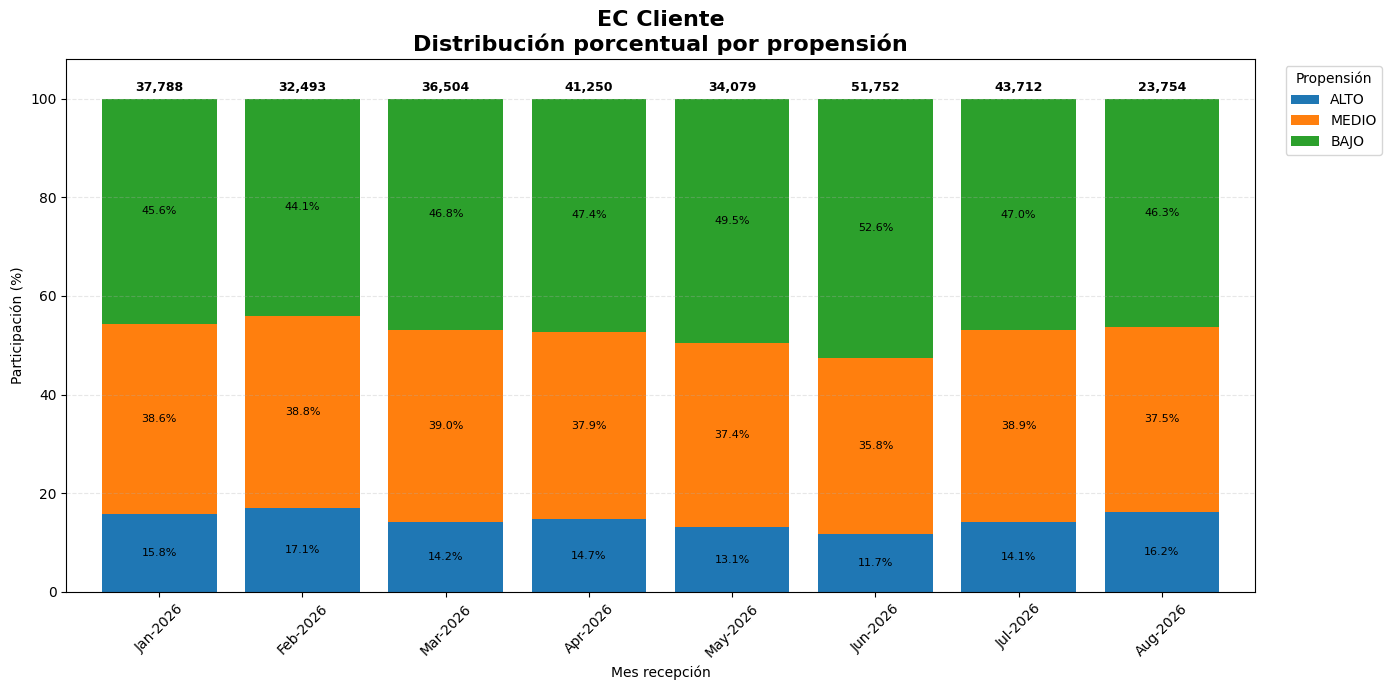

PROPENSION,ALTO,MEDIO,BAJO,Total Base
mes,,,,
2026-01-01,15.77%,38.63%,45.60%,37788
2026-02-01,17.10%,38.81%,44.10%,32493
2026-03-01,14.16%,39.01%,46.82%,36504
2026-04-01,14.71%,37.94%,47.35%,41250
2026-05-01,13.08%,37.42%,49.49%,34079
2026-06-01,11.65%,35.79%,52.56%,51752
2026-07-01,14.09%,38.92%,46.99%,43712
2026-08-01,16.20%,37.53%,46.28%,23754


In [61]:
import pandas as pd
import numpy as np

# ============================================================
# CAMBIAR ÚNICAMENTE EL PRODUCTO
# ============================================================
producto_seleccionado = "Reenganche EC"

# Orden de presentación
orden_propension = ['1','2','3','4','5','6','7','8','9','10']

# ============================================================
# 1. FILTRAR Y PREPARAR LOS DATOS
# ============================================================
df_tabla = df_filtrado[
    df_filtrado["producto"] == producto_seleccionado
].copy()

# Convertir mes
df_tabla["mes"] = pd.to_datetime(
    df_tabla["mes"],
    errors="coerce"
)

# Convertir columnas numéricas
columnas_numericas = [
    "cantidad",
    "linea_sae_sum",
    "linea_sae_count",
    "tea_sum",
    "tea_count"
]

for columna in columnas_numericas:
    df_tabla[columna] = pd.to_numeric(
        df_tabla[columna],
        errors="coerce"
    ).fillna(0)

# Limpiar propensión
df_tabla["PROPENSION"] = (
    df_tabla["PROPENSION"]
    .fillna("SIN PROPENSION")
    .astype(str)
    .str.strip()
    .str.upper()
)

# Conservar solamente ALTO, MEDIO y BAJO
df_tabla = df_tabla[
    df_tabla["PROPENSION"].isin(orden_propension)
].copy()

# Eliminar filas sin mes
df_tabla = df_tabla.dropna(subset=["mes"])

# ============================================================
# 2. AGRUPAR POR MES Y PROPENSIÓN
# ============================================================
df_resumen = (
    df_tabla
    .groupby(
        ["mes", "PROPENSION"],
        as_index=False
    )
    .agg(
        cantidad=("cantidad", "sum"),
        linea_sae_sum=("linea_sae_sum", "sum"),
        linea_sae_count=("linea_sae_count", "sum"),
        tea_sum=("tea_sum", "sum"),
        tea_count=("tea_count", "sum")
    )
)

# ============================================================
# 3. CALCULAR PROMEDIOS PONDERADOS
# ============================================================
df_resumen["Promedio_linea_sae"] = np.where(
    df_resumen["linea_sae_count"] > 0,
    df_resumen["linea_sae_sum"]
    / df_resumen["linea_sae_count"],
    np.nan
)

# La TEA está almacenada como decimal:
# 0.6955 equivale a 69.55 %
df_resumen["Promedio_TEA"] = np.where(
    df_resumen["tea_count"] > 0,
    (
        df_resumen["tea_sum"]
        / df_resumen["tea_count"]
    ) * 100,
    np.nan
)

# ============================================================
# 4. TOTAL DE LA BASE POR MES
# ============================================================
df_total_mes = (
    df_resumen
    .groupby("mes", as_index=False)["cantidad"]
    .sum()
    .rename(
        columns={
            "cantidad": "Total Base"
        }
    )
)

df_resumen = df_resumen.merge(
    df_total_mes,
    on="mes",
    how="left"
)

# Participación de cada propensión dentro del mes
df_resumen["Participacion"] = np.where(
    df_resumen["Total Base"] > 0,
    (
        df_resumen["cantidad"]
        / df_resumen["Total Base"]
    ) * 100,
    0
)

# ============================================================
# 5. CREAR TABLAS PIVOT
# ============================================================

# Participación porcentual
tabla_participacion = (
    df_resumen
    .pivot(
        index="mes",
        columns="PROPENSION",
        values="Participacion"
    )
)

# Línea SAE promedio
tabla_linea_sae = (
    df_resumen
    .pivot(
        index="mes",
        columns="PROPENSION",
        values="Promedio_linea_sae"
    )
)

# TEA promedio
tabla_tea = (
    df_resumen
    .pivot(
        index="mes",
        columns="PROPENSION",
        values="Promedio_TEA"
    )
)

# Cantidad por propensión
tabla_cantidad = (
    df_resumen
    .pivot(
        index="mes",
        columns="PROPENSION",
        values="cantidad"
    )
)

# Asegurar que las columnas estén en orden
for propension in orden_propension:

    if propension not in tabla_participacion.columns:
        tabla_participacion[propension] = 0

    if propension not in tabla_linea_sae.columns:
        tabla_linea_sae[propension] = np.nan

    if propension not in tabla_tea.columns:
        tabla_tea[propension] = np.nan

    if propension not in tabla_cantidad.columns:
        tabla_cantidad[propension] = 0

tabla_participacion = tabla_participacion[orden_propension]
tabla_linea_sae = tabla_linea_sae[orden_propension]
tabla_tea = tabla_tea[orden_propension]
tabla_cantidad = tabla_cantidad[orden_propension]

# ============================================================
# 6. ARMAR TABLA FINAL
# ============================================================
df_tabla_final = pd.DataFrame(
    index=tabla_participacion.index
)

# Total mensual
df_tabla_final["Total Base"] = (
    tabla_cantidad.sum(axis=1)
)

# Columnas por propensión
for propension in orden_propension:

    df_tabla_final[
        f"% {propension}"
    ] = tabla_participacion[propension]

    df_tabla_final[
        f"Línea SAE {propension}"
    ] = tabla_linea_sae[propension]

    df_tabla_final[
        f"TEA {propension}"
    ] = tabla_tea[propension]

# ============================================================
# 7. FILA CONSOLIDADA DEL PERIODO
# ============================================================
df_periodo = (
    df_tabla
    .groupby(
        "PROPENSION",
        as_index=False
    )
    .agg(
        cantidad=("cantidad", "sum"),
        linea_sae_sum=("linea_sae_sum", "sum"),
        linea_sae_count=("linea_sae_count", "sum"),
        tea_sum=("tea_sum", "sum"),
        tea_count=("tea_count", "sum")
    )
)

total_periodo = df_periodo["cantidad"].sum()

fila_periodo = {
    "Total Base": total_periodo
}

for propension in orden_propension:

    datos = df_periodo[
        df_periodo["PROPENSION"] == propension
    ]

    if not datos.empty:

        cantidad_propension = datos["cantidad"].iloc[0]

        participacion = (
            cantidad_propension / total_periodo * 100
            if total_periodo > 0
            else 0
        )

        promedio_linea = (
            datos["linea_sae_sum"].iloc[0]
            / datos["linea_sae_count"].iloc[0]
            if datos["linea_sae_count"].iloc[0] > 0
            else np.nan
        )

        promedio_tea = (
            datos["tea_sum"].iloc[0]
            / datos["tea_count"].iloc[0]
            * 100
            if datos["tea_count"].iloc[0] > 0
            else np.nan
        )

    else:

        participacion = 0
        promedio_linea = np.nan
        promedio_tea = np.nan

    fila_periodo[f"% {propension}"] = participacion
    fila_periodo[f"Línea SAE {propension}"] = promedio_linea
    fila_periodo[f"TEA {propension}"] = promedio_tea

# Cambiar el índice mensual a texto
df_tabla_final.index = [
    fecha.strftime("%B %Y").capitalize()
    for fecha in df_tabla_final.index
]

# Agregar fila consolidada
df_tabla_final.loc["TOTAL PERIODO"] = fila_periodo

# ============================================================
# 8. DAR FORMATO PARA MOSTRAR
# ============================================================
df_tabla_mostrar = df_tabla_final.copy()

# Total base como entero con separador de miles
df_tabla_mostrar["Total Base"] = (
    df_tabla_mostrar["Total Base"]
    .fillna(0)
    .map(lambda valor: f"{valor:,.0f}")
)

for propension in orden_propension:

    # Participación
    df_tabla_mostrar[f"% {propension}"] = (
        df_tabla_mostrar[f"% {propension}"]
        .map(
            lambda valor:
            f"{valor:.2f}%"
            if pd.notna(valor)
            else "-"
        )
    )

    # Línea SAE
    df_tabla_mostrar[f"Línea SAE {propension}"] = (
        df_tabla_mostrar[f"Línea SAE {propension}"]
        .map(
            lambda valor:
            f"S/ {valor:,.2f}"
            if pd.notna(valor)
            else "-"
        )
    )

    # TEA
    df_tabla_mostrar[f"TEA {propension}"] = (
        df_tabla_mostrar[f"TEA {propension}"]
        .map(
            lambda valor:
            f"{valor:.2f}%"
            if pd.notna(valor)
            else "-"
        )
    )

# Nombre del índice
df_tabla_mostrar.index.name = "Mes de recepción"

# ============================================================
# 9. MOSTRAR TABLA
# ============================================================
display(df_tabla_mostrar)

,Total Base,% 1,Línea SAE 1,TEA 1,% 2,Línea SAE 2,TEA 2,% 3,Línea SAE 3,TEA 3,...,TEA 7,% 8,Línea SAE 8,TEA 8,% 9,Línea SAE 9,TEA 9,% 10,Línea SAE 10,TEA 10
Mes de recepción,,,,,,,,,,,,,,,,,,,,,
January 2026,"1,257",64.04%,"S/ 12,911.30",46.19%,22.04%,"S/ 15,025.63",35.57%,7.16%,"S/ 17,538.89",30.77%,...,-,-,-,-,-,-,-,-,-,-
February 2026,"1,817",67.47%,"S/ 13,092.90",46.82%,18.82%,"S/ 14,777.19",35.13%,7.82%,"S/ 17,200.70",32.18%,...,20.90%,0.06%,"S/ 6,700.00",39.90%,-,-,-,-,-,-
March 2026,"1,766",65.18%,"S/ 12,855.87",39.90%,21.18%,"S/ 15,488.50",-,7.47%,"S/ 17,337.88",-,...,-,0.06%,"S/ 19,200.00",-,-,-,-,-,-,-
April 2026,"1,539",65.63%,"S/ 13,165.94",46.09%,20.27%,"S/ 15,110.26",35.83%,8.32%,"S/ 18,703.12",31.32%,...,27.90%,-,-,-,-,-,-,-,-,-
May 2026,"1,454",66.51%,"S/ 13,053.36",47.64%,19.39%,"S/ 14,502.13",37.56%,7.63%,"S/ 16,957.66",31.34%,...,20.90%,0.14%,"S/ 20,000.00",10.45%,-,-,-,0.07%,"S/ 20,100.00",20.90%
June 2026,"2,101",38.32%,"S/ 13,932.92",41.33%,17.71%,"S/ 14,938.44",34.79%,37.55%,"S/ 15,231.94",39.65%,...,27.90%,0.10%,"S/ 20,850.00",27.90%,0.05%,"S/ 25,000.00",20.90%,0.05%,"S/ 11,600.00",20.90%
July 2026,"1,921",52.42%,"S/ 13,614.70",40.68%,27.49%,"S/ 15,025.00",34.11%,11.19%,"S/ 17,090.23",31.55%,...,21.70%,0.10%,"S/ 23,500.00",20.90%,0.05%,"S/ 25,000.00",20.90%,-,-,-
August 2026,"1,509",56.20%,"S/ 12,739.74",43.74%,26.64%,"S/ 15,197.76",34.66%,9.21%,"S/ 16,226.62",30.68%,...,14.45%,-,-,-,-,-,-,-,-,-
TOTAL PERIODO,"13,364",58.51%,"S/ 13,159.24",44.77%,21.62%,"S/ 15,026.79",35.20%,13.06%,"S/ 16,342.38",35.42%,...,21.30%,0.06%,"S/ 19,325.00",22.63%,0.01%,"S/ 25,000.00",20.90%,0.01%,"S/ 15,850.00",20.90%


In [62]:
import pandas as pd
import numpy as np

# ============================================================
# CAMBIAR ÚNICAMENTE EL PRODUCTO
# ============================================================
producto_seleccionado = "Reenganche EC"

# ============================================================
# 1. FILTRAR Y PREPARAR LOS DATOS
# ============================================================
df_tabla = df_filtrado[
    df_filtrado["producto"] == producto_seleccionado
].copy()

df_tabla["mes"] = pd.to_datetime(
    df_tabla["mes"],
    errors="coerce"
)

columnas_numericas = [
    "cantidad",
    "linea_sae_sum",
    "linea_sae_count",
    "tea_sum",
    "tea_count"
]

for columna in columnas_numericas:
    df_tabla[columna] = pd.to_numeric(
        df_tabla[columna],
        errors="coerce"
    ).fillna(0)

# Eliminar registros sin mes
df_tabla = df_tabla.dropna(subset=["mes"])

# ============================================================
# 2. AGRUPAR SOLAMENTE POR MES
# No se considera PROPENSION
# ============================================================
df_resumen_mensual = (
    df_tabla
    .groupby(
        "mes",
        as_index=False
    )
    .agg(
        total_base=("cantidad", "sum"),
        linea_sae_sum=("linea_sae_sum", "sum"),
        linea_sae_count=("linea_sae_count", "sum"),
        tea_sum=("tea_sum", "sum"),
        tea_count=("tea_count", "sum")
    )
    .sort_values("mes")
)

# ============================================================
# 3. CALCULAR PROMEDIOS PONDERADOS
# ============================================================
df_resumen_mensual["Promedio Línea SAE"] = np.where(
    df_resumen_mensual["linea_sae_count"] > 0,
    (
        df_resumen_mensual["linea_sae_sum"]
        / df_resumen_mensual["linea_sae_count"]
    ),
    np.nan
)

# TEA almacenada como decimal:
# 0.50 equivale a 50 %
df_resumen_mensual["Promedio TEA"] = np.where(
    df_resumen_mensual["tea_count"] > 0,
    (
        df_resumen_mensual["tea_sum"]
        / df_resumen_mensual["tea_count"]
    ) * 100,
    np.nan
)

# ============================================================
# 4. SELECCIONAR COLUMNAS FINALES
# ============================================================
df_tabla_final = df_resumen_mensual[
    [
        "mes",
        "total_base",
        "Promedio Línea SAE",
        "Promedio TEA"
    ]
].copy()

df_tabla_final = df_tabla_final.rename(
    columns={
        "mes": "Mes de recepción",
        "total_base": "Total Base"
    }
)

# ============================================================
# 5. FILA TOTAL DEL PERIODO
# ============================================================
total_base_periodo = df_tabla["cantidad"].sum()

total_linea_sum = df_tabla["linea_sae_sum"].sum()
total_linea_count = df_tabla["linea_sae_count"].sum()

total_tea_sum = df_tabla["tea_sum"].sum()
total_tea_count = df_tabla["tea_count"].sum()

promedio_linea_periodo = (
    total_linea_sum / total_linea_count
    if total_linea_count > 0
    else np.nan
)

promedio_tea_periodo = (
    total_tea_sum / total_tea_count * 100
    if total_tea_count > 0
    else np.nan
)

fila_total = pd.DataFrame({
    "Mes de recepción": ["TOTAL PERIODO"],
    "Total Base": [total_base_periodo],
    "Promedio Línea SAE": [promedio_linea_periodo],
    "Promedio TEA": [promedio_tea_periodo]
})

# Convertir meses a texto antes de concatenar
df_tabla_final["Mes de recepción"] = (
    df_tabla_final["Mes de recepción"]
    .dt.strftime("%B %Y")
    .str.capitalize()
)

df_tabla_final = pd.concat(
    [
        df_tabla_final,
        fila_total
    ],
    ignore_index=True
)

# ============================================================
# 6. DAR FORMATO PARA MOSTRAR
# ============================================================
df_tabla_mostrar = df_tabla_final.copy()

df_tabla_mostrar["Total Base"] = (
    df_tabla_mostrar["Total Base"]
    .fillna(0)
    .map(lambda valor: f"{valor:,.0f}")
)

df_tabla_mostrar["Promedio Línea SAE"] = (
    df_tabla_mostrar["Promedio Línea SAE"]
    .map(
        lambda valor:
        f"S/ {valor:,.2f}"
        if pd.notna(valor)
        else "-"
    )
)

df_tabla_mostrar["Promedio TEA"] = (
    df_tabla_mostrar["Promedio TEA"]
    .map(
        lambda valor:
        f"{valor:.2f}%"
        if pd.notna(valor)
        else "-"
    )
)

# ============================================================
# 7. MOSTRAR TABLA
# ============================================================
display(df_tabla_mostrar)

,Mes de recepción,Total Base,Promedio Línea SAE,Promedio TEA
0,January 2026,"1,257","S/ 14,178.28",41.47%
1,February 2026,"1,817","S/ 14,100.28",42.40%
2,March 2026,"1,766","S/ 14,241.79",39.90%
3,April 2026,"1,539","S/ 14,325.86",41.74%
4,May 2026,"1,454","S/ 14,129.09",43.19%
5,June 2026,"2,101","S/ 15,002.86",38.64%
6,July 2026,"1,921","S/ 14,944.14",36.71%
7,August 2026,"1,509","S/ 14,375.28",38.56%
8,TOTAL PERIODO,"13,364","S/ 14,449.68",40.19%
